Bài toán: Vietnamese Sentiment Analysis

Dataset: UIT-VSFC

Kiến trúc: PhoBERT

Task: Binary classification (2 nhãn: positive / negative)

# Import thư viện

In [ ]:
!pip install py-vncorenlp
!pip install gdown
!pip install -q torchinfo
!pip install wandb

In [ ]:
import pandas as pd
import numpy as np
import random
import os
import importlib
import sys
import subprocess
import time
import re
import unicodedata
import py_vncorenlp
import logging
import torch
import transformers
import gdown
import torch
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
import csv

from dataclasses import fields
from datasets import load_dataset, Dataset
from py_vncorenlp import VnCoreNLP
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from transformers import TrainingArguments
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from transformers import Trainer, EarlyStoppingCallback
from torchinfo import summary
from transformers.integrations import WandbCallback
from sklearn.metrics import confusion_matrix, f1_score, recall_score
from sklearn.metrics import classification_report

# Kiểm tra môi trường


In [ ]:
import importlib, sys, os, subprocess
G = "\033[92m"; R = "\033[91m"; Y = "\033[93m"; B = "\033[94m"
BOLD = "\033[1m"; RESET = "\033[0m"
OK   = f"{G}✔ OK{RESET}"
FAIL = f"{R}✗ THIẾU{RESET}"
WARN = f"{Y}⚠  WARN{RESET}"

def check_pkg(import_name, version_attr="__version__"):
    try:
        mod = importlib.import_module(import_name)
        ver = getattr(mod, version_attr, "?")
        return True, str(ver)
    except Exception:
        return False, None

def section(title):
    print(f"\n{BOLD}{B}{'─'*55}")
    print(f"  {title}")
    print(f"{'─'*55}{RESET}")

def row(label, ok, ver=None, note=""):
    tag      = OK if ok else FAIL
    ver_str  = f"  v{ver}" if ver and ver != "?" else ""
    col      = G if ok else Y
    note_str = f"  {col}({note}){RESET}" if note else ""
    print(f"  {tag}  {label:<40}{ver_str}{note_str}")

# ════════════════════════════════════════════════════
print(f"\n{BOLD}{'═'*55}")
print("   KIỂM TRA MÔI TRƯỜNG — TRANSFORMERS / HuggingFace")
print(f"{'═'*55}{RESET}")

# ── 1. Python ────────────────────────────────────────
section("1. Python")
pv  = sys.version.split()[0]
ok  = tuple(int(x) for x in pv.split(".")[:2]) >= (3, 8)
row("Python ≥ 3.8", ok, pv)

# ── 2. Core ML / DL ──────────────────────────────────
section("2. Core ML / DL")

ok, ver = check_pkg("torch")
row("torch (PyTorch)", ok, ver,
    "cần ≥ 1.12" if ok and ver and ver < "1.12" else "")

if ok:
    try:
        import torch as _torch
        cuda_ok  = _torch.cuda.is_available()
        cuda_ver = _torch.version.cuda or "N/A"
        tag  = OK if cuda_ok else WARN
        note = f"CUDA {cuda_ver}" if cuda_ok else "Chạy trên CPU — CUDA không khả dụng"
        col  = G if cuda_ok else Y
        print(f"  {tag}  {'torch.cuda':<40}  {col}({note}){RESET}")
    except Exception:
        pass

ok, ver = check_pkg("numpy")
row("numpy", ok, ver)

ok, ver = check_pkg("pandas")
row("pandas", ok, ver)

ok, ver = check_pkg("sklearn")
row("scikit-learn", ok, ver)

ok, ver = check_pkg("matplotlib")
row("matplotlib", ok, ver)

ok, ver = check_pkg("seaborn")
row("seaborn", ok, ver)

# ── 3. HuggingFace Ecosystem ─────────────────────────
section("3. HuggingFace Ecosystem")

hf_pkgs = [
    ("transformers",  "transformers",  "cần ≥ 4.30"),
    ("datasets",      "datasets",      ""),
    ("tokenizers",    "tokenizers",    ""),
    ("accelerate",    "accelerate",    ""),
    ("evaluate",      "evaluate",      ""),
    ("peft",          "peft",          "LoRA / adapter fine-tuning"),
    ("trl",           "trl",           "SFT / RLHF training"),
    ("huggingface_hub","huggingface_hub","push_to_hub, login"),
]
for label, imp, note_hint in hf_pkgs:
    ok, ver = check_pkg(imp)
    note = ""
    if ok and note_hint and note_hint.startswith("cần"):
        note = note_hint if ver and ver < note_hint.split("≥")[1].strip() else ""
    elif note_hint and not note_hint.startswith("cần"):
        note = note_hint if ok else ""
    row(label, ok, ver, note)

# HuggingFace Hub login
try:
    from huggingface_hub import HfApi as _HfApi
    try:
        token = _HfApi().token
        logged_in = bool(token)
    except Exception:
        logged_in = False
    tag  = OK if logged_in else WARN
    col  = G if logged_in else Y
    note = "Đã login" if logged_in else "Chưa login — chạy: huggingface-cli login"
    print(f"  {tag}  {'HuggingFace Hub login':<40}  {col}({note}){RESET}")
except Exception:
    pass

# ── 4. NLP tiếng Việt ────────────────────────────────
section("4. NLP tiếng Việt")

ok, ver = check_pkg("py_vncorenlp")
row("py_vncorenlp", ok, ver)

if ok:
    vncorenlp_paths = [
        os.path.expanduser("~/vncorenlp"),
        "/content/vncorenlp",
        "./vncorenlp",
    ]
    model_found = any(
        os.path.isfile(os.path.join(p, "VnCoreNLP-1.2.jar"))
        for p in vncorenlp_paths
    )
    tag  = OK if model_found else WARN
    col  = G if model_found else Y
    note = "VnCoreNLP-1.2.jar tìm thấy" if model_found else "Chưa thấy VnCoreNLP-1.2.jar"
    print(f"  {tag}  {'VnCoreNLP model file':<40}  {col}({note}){RESET}")

# Kiểm tra PhoBERT có thể load không
try:
    from transformers import AutoTokenizer as _AT
    _AT.from_pretrained("vinai/phobert-base", local_files_only=True)
    print(f"  {OK}  {'PhoBERT cache (vinai/phobert-base)':<40}  {G}(cache sẵn sàng){RESET}")
except Exception:
    print(f"  {WARN}  {'PhoBERT cache (vinai/phobert-base)':<40}  {Y}(Chưa cache — sẽ tải khi chạy lần đầu){RESET}")

# ── 5. Logging & Utilities ───────────────────────────
section("5. Logging & Utilities")

ok, ver = check_pkg("wandb")
row("wandb", ok, ver)

if ok:
    try:
        import wandb as _wandb
        api_key   = _wandb.api.api_key if hasattr(_wandb, "api") else None
        logged_in = bool(api_key)
    except Exception:
        logged_in = False
    tag  = OK if logged_in else WARN
    col  = G if logged_in else Y
    note = "Đã login" if logged_in else "Chưa login — chạy wandb.login()"
    print(f"  {tag}  {'wandb login':<40}  {col}({note}){RESET}")

ok, ver = check_pkg("gdown")
row("gdown", ok, ver)

ok, ver = check_pkg("sentencepiece")
row("sentencepiece", ok, ver,
    "cần cho một số tokenizer (BERT-based)" if ok else "")

ok, ver = check_pkg("scipy")
row("scipy", ok, ver)

# ── 6. Transformers Modules ──────────────────────────
section("6. Transformers Modules")

tf_items = [
    ("AutoTokenizer",           "transformers", "AutoTokenizer"),
    ("AutoModel",               "transformers", "AutoModel"),
    ("AutoModelForSequenceClassification", "transformers", "AutoModelForSequenceClassification"),
    ("AutoModelForTokenClassification",    "transformers", "AutoModelForTokenClassification"),
    ("BertTokenizerFast",       "transformers", "BertTokenizerFast"),
    ("RobertaTokenizerFast",    "transformers", "RobertaTokenizerFast"),
    ("Trainer",                 "transformers", "Trainer"),
    ("TrainingArguments",       "transformers", "TrainingArguments"),
    ("DataCollatorWithPadding", "transformers", "DataCollatorWithPadding"),
    ("EarlyStoppingCallback",   "transformers", "EarlyStoppingCallback"),
    ("pipeline",                "transformers", "pipeline"),
]
for label, module, attr in tf_items:
    try:
        mod = importlib.import_module(module)
        getattr(mod, attr)
        row(label, True)
    except Exception:
        row(label, False, note=f"not found in {module}")

# DatasetDict từ datasets
try:
    from datasets import DatasetDict, load_dataset  # noqa
    row("DatasetDict / load_dataset", True)
except Exception:
    row("DatasetDict / load_dataset", False)

# WandbCallback
try:
    from transformers.integrations import WandbCallback  # noqa
    row("WandbCallback (transformers)", True)
except Exception:
    row("WandbCallback (transformers)", False,
        note="Dùng wandb.log() trực tiếp thay thế")

# ── 7. GPU / Hardware ────────────────────────────────
section("7. GPU / Hardware")

try:
    import torch as _torch
    gpus = _torch.cuda.device_count()
    if gpus > 0:
        for i in range(gpus):
            name = _torch.cuda.get_device_name(i)
            row(f"GPU {i}: {name}", True, note="sẵn sàng")
        # VRAM
        try:
            result = subprocess.run(
                ["nvidia-smi", "--query-gpu=name,memory.total",
                 "--format=csv,noheader,nounits"],
                capture_output=True, text=True, timeout=5,
            )
            if result.returncode == 0:
                for line in result.stdout.strip().splitlines():
                    name, mem = line.split(",")
                    vram_gb   = int(mem.strip()) / 1024
                    ok_vram   = vram_gb >= 8
                    row(
                        f"VRAM ({name.strip()})", ok_vram,
                        note=f"{vram_gb:.1f} GB {'≥8GB ✔ (PhoBERT fine-tune OK)' if ok_vram else '< 8GB — dùng gradient_accumulation_steps'}"
                    )
        except Exception:
            pass
    else:
        print(f"  {WARN}  {'GPU':<40}  {Y}(Không tìm thấy — chạy trên CPU){RESET}")

    # cuDNN
    cudnn_ok = _torch.backends.cudnn.is_available()
    row("cuDNN", cudnn_ok,
        str(_torch.backends.cudnn.version()) if cudnn_ok else None,
        "cuDNN không khả dụng" if not cudnn_ok else "")

    # Mixed precision (fp16 / bf16)
    fp16_ok  = _torch.cuda.is_available() and _torch.cuda.get_device_capability()[0] >= 7
    bf16_ok  = _torch.cuda.is_available() and _torch.cuda.is_bf16_supported()
    row("fp16 (mixed precision)",  fp16_ok,  note="Volta+ (SM ≥ 7.0) required" if not fp16_ok else "")
    row("bf16 (bfloat16 support)", bf16_ok,  note="Ampere+ required"           if not bf16_ok else "")

except Exception as e:
    print(f"  {FAIL}  Không kiểm tra được GPU: {e}")

# ── 8. Google Colab ──────────────────────────────────
section("8. Google Colab")
try:
    from google.colab import files as _cf  # noqa
    row("google.colab", True, note="Đang chạy trong Colab ✓")

    # Kiểm tra Drive đã mount chưa
    drive_mounted = os.path.isdir("/content/drive/MyDrive")
    tag  = OK if drive_mounted else WARN
    col  = G if drive_mounted else Y
    note = "Đã mount tại /content/drive" if drive_mounted else "Chưa mount — chạy: drive.mount('/content/drive')"
    print(f"  {tag}  {'Google Drive':<40}  {col}({note}){RESET}")
except ImportError:
    print(f"  {WARN}  {'google.colab':<40}  {Y}(Không phải Colab — import sẽ lỗi){RESET}")

# ── Tóm tắt & lệnh cài ───────────────────────────────
print(f"\n{BOLD}{'═'*55}")
print("   CÁC PACKAGE CÒN THIẾU — LỆNH CÀI ĐẶT")
print(f"{'═'*55}{RESET}")

pkgs_map = {
    "torch":             "torch",
    "numpy":             "numpy",
    "pandas":            "pandas",
    "sklearn":           "scikit-learn",
    "matplotlib":        "matplotlib",
    "seaborn":           "seaborn",
    "transformers":      "transformers",
    "datasets":          "datasets",
    "tokenizers":        "tokenizers",
    "accelerate":        "accelerate",
    "evaluate":          "evaluate",
    "peft":              "peft",
    "trl":               "trl",
    "huggingface_hub":   "huggingface_hub",
    "py_vncorenlp":      "py_vncorenlp",
    "wandb":             "wandb",
    "gdown":             "gdown",
    "sentencepiece":     "sentencepiece",
    "scipy":             "scipy",
}

missing = [pip for imp, pip in pkgs_map.items() if not check_pkg(imp)[0]]

if missing:
    print(f"\n  {R}Thiếu:{RESET} {', '.join(missing)}")
    print(f"\n  {BOLD}Chạy cell sau để cài:{RESET}")
    print(f"\n  {G}!pip install -q {' '.join(missing)}{RESET}")
    if "torch" in missing:
        print(f"\n  {Y}Hoặc cài PyTorch với CUDA (Colab A100/V100):{RESET}")
        print(f"  {G}!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118{RESET}")
    if "transformers" in missing:
        print(f"\n  {Y}Hoặc cài transformers bản mới nhất từ GitHub:{RESET}")
        print(f"  {G}!pip install -q git+https://github.com/huggingface/transformers{RESET}")
else:
    print(f"\n  {G}{BOLD}Tất cả package đã sẵn sàng! 🎉{RESET}")

print()


═══════════════════════════════════════════════════════
   KIỂM TRA MÔI TRƯỜNG — TRANSFORMERS / HuggingFace
═══════════════════════════════════════════════════════

───────────────────────────────────────────────────────
  1. Python
───────────────────────────────────────────────────────
  ✔ OK  Python ≥ 3.8                              v3.12.13

───────────────────────────────────────────────────────
  2. Core ML / DL
───────────────────────────────────────────────────────
  ✔ OK  torch (PyTorch)                           v2.11.0+cu128
  ✔ OK  torch.cuda                                (CUDA 12.8)
  ✔ OK  numpy                                     v2.0.2
  ✔ OK  pandas                                    v2.2.2
  ✔ OK  scikit-learn                              v1.6.1
  ✔ OK  matplotlib                                v3.10.0
  ✔ OK  seaborn                                   v0.13.2

───────────────────────────────────────────────────────
  3. HuggingFace Ecosystem
───────────────────────

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


  ⚠  WARN  wandb login                               (Chưa login — chạy wandb.login())
  ✔ OK  gdown                                     v5.2.2
  ✔ OK  sentencepiece                             v0.2.2  (cần cho một số tokenizer (BERT-based))
  ✔ OK  scipy                                     v1.16.3

───────────────────────────────────────────────────────
  6. Transformers Modules
───────────────────────────────────────────────────────
  ✔ OK  AutoTokenizer                           
  ✔ OK  AutoModel                               
  ✔ OK  AutoModelForSequenceClassification      
  ✔ OK  AutoModelForTokenClassification         
  ✔ OK  BertTokenizerFast                       
  ✔ OK  RobertaTokenizerFast                    
  ✔ OK  Trainer                                 
  ✔ OK  TrainingArguments                       
  ✔ OK  DataCollatorWithPadding                 
  ✔ OK  EarlyStoppingCallback                   
  ✔ OK  pipeline                                
  ✔ OK  DatasetDict / 

# 1. Load Dataset

## Tải dataset từ drive và kiểm tra dataset

In [ ]:
def dowload_dataset(drive_url, output):
    try:
        gdown.download(drive_url, output, quiet=False)
        print(f"File downloaded successfully to {output}")
    except Exception as e:
        print(f"An error occurred: {e}")

In [ ]:
def read_csv_file(csv_url):
    try:
        df = pd.read_csv(csv_url)
        return df
    except Exception as e:
        print(f"An error occurred: {e}")

In [ ]:
train_url = "https://drive.google.com/uc?id=1bH_UtyfqKiWvbv_dMxh2chs7C0OOPNcP"
valid_url = "https://drive.google.com/uc?id=1i6coNGTj7ZMmbhcjSA8aaawpfHlrQf0Z"
test_url = "https://drive.google.com/uc?id=1Mvh2p4jX6PkS84c7EpIimly3YoeNpP-t"
train_output = "train_data_uit_vsfc.csv"
valid_output = "valid_data_uit_vsfc.csv"
test_output = "test_data_uit_vsfc.csv"

In [ ]:
dowload_dataset(train_url, train_output)
dowload_dataset(valid_url, valid_output)
dowload_dataset(test_url, test_output)


Downloading...
From: https://drive.google.com/uc?id=1bH_UtyfqKiWvbv_dMxh2chs7C0OOPNcP
To: /content/train_data_uit_vsfc.csv
100%|██████████| 1.02M/1.02M [00:00<00:00, 28.5MB/s]


File downloaded successfully to train_data_uit_vsfc.csv


Downloading...
From: https://drive.google.com/uc?id=1i6coNGTj7ZMmbhcjSA8aaawpfHlrQf0Z
To: /content/valid_data_uit_vsfc.csv
100%|██████████| 281k/281k [00:00<00:00, 36.2MB/s]


File downloaded successfully to valid_data_uit_vsfc.csv


Downloading...
From: https://drive.google.com/uc?id=1Mvh2p4jX6PkS84c7EpIimly3YoeNpP-t
To: /content/test_data_uit_vsfc.csv
100%|██████████| 135k/135k [00:00<00:00, 47.7MB/s]

File downloaded successfully to test_data_uit_vsfc.csv


In [ ]:
train_df = pd.read_csv(train_output)
val_df = read_csv_file(valid_output)
test_df = read_csv_file(test_output)

In [ ]:
#import pandas as pd

#full_df = pd.concat(
#    [train_df, val_df, test_df],
#    axis=0,
#    ignore_index=True
#)

## một vài thông tin về dataset

In [ ]:
print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

print("\nDataset info: ")
print("\nTrain DataFrame head:\n", train_df.head())
print("\nValidation DataFrame head:\n", val_df.head())
print("\nTest DataFrame head:\n", test_df.head())

Train size: 11426
Validation size: 3166
Test size: 1583

Dataset info: 

Train DataFrame head:
    id                                           sentence  sentiment  topic
0   0                          slide giáo trình đầy đủ .          2      1
1   1     nhiệt tình giảng dạy , gần gũi với sinh viên .          2      0
2   2               đi học đầy đủ full điểm chuyên cần .          0      1
3   3  chưa áp dụng công nghệ thông tin và các thiết ...          0      0
4   4  thầy giảng bài hay , có nhiều bài tập ví dụ ng...          2      0

Validation DataFrame head:
    id                                           sentence  sentiment  topic
0   0                           nói tiếng anh lưu loát .          2      0
1   1                           giáo viên rất vui tính .          2      0
2   2                                    cô max có tâm .          2      0
3   3                       giảng bài thu hút , dí dỏm .          2      0
4   4  giáo viên không giảng dạy kiến thức , hướng

In [ ]:
print('Thông tin về tập train: ')
train_df.info()
print('\nThông tin về tập validation: ')
val_df.info()
print('\nThông tin về tập test: ')
test_df.info()

Thông tin về tập train: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11426 entries, 0 to 11425
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         11426 non-null  int64 
 1   sentence   11426 non-null  object
 2   sentiment  11426 non-null  int64 
 3   topic      11426 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 357.2+ KB

Thông tin về tập validation: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3166 entries, 0 to 3165
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         3166 non-null   int64 
 1   sentence   3166 non-null   object
 2   sentiment  3166 non-null   int64 
 3   topic      3166 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 99.1+ KB

Thông tin về tập test: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1583 entries, 0 to 1582
Data columns (total 4 columns):
 #   Column     Non-Null Cou

# 2. preprocessing

## thay đổi tên các cột

In [ ]:
train_df = train_df.rename(columns={'sentence': 'text', 'sentiment': 'label'})
val_df = val_df.rename(columns={'sentence': 'text', 'sentiment': 'label'})
test_df = test_df.rename(columns={'sentence': 'text', 'sentiment': 'label'})

## loại bỏ các label có giá trị NaN

In [ ]:
# ✅ Kiểm tra NaN trước
print(train_df.isnull().sum())
print(val_df.isnull().sum())
print(test_df.isnull().sum())

# ✅ Loại bỏ NaN
train_df = train_df.dropna().reset_index(drop=True)
val_df   = val_df.dropna().reset_index(drop=True)
test_df  = test_df.dropna().reset_index(drop=True)

# ✅ Kiểm tra lại
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

id       0
text     0
label    0
topic    0
dtype: int64
id       0
text     0
label    0
topic    0
dtype: int64
id       0
text     0
label    0
topic    0
dtype: int64
Train: 11426 | Val: 3166 | Test: 1583


## Loại bỏ nhãn neutral

In [ ]:
# chuẩn hóa nhãn (label) cho bài toán phân loại cảm xúc nhị phân

#1. Định nghĩa ánh xạ nhãn
label_map = {
    0 : 0,
    2 : 1
}

# Loại bỏ nhãn neutral cho 3 tập train/valid/test
train_df = train_df[train_df['label'] != 1].reset_index(drop=True)
val_df = val_df[val_df['label'] != 1].reset_index(drop=True)
test_df = test_df[test_df['label'] != 1].reset_index(drop=True)

# Áp dụng ánh xạ cho 3 tập train/valid/test
train_df['label'] = train_df['label'].map(label_map).astype(int)
val_df['label'] = val_df['label'].map(label_map).astype(int)
test_df['label'] = test_df['label'].map(label_map).astype(int)

# ✅ Kiểm tra lại
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 10968 | Val: 2999 | Test: 1510


## chuẩn hóa văn bản

In [ ]:

# Kiểm tra kiểu dữ liệu đầu vào
def normalize_text(text):
    if not isinstance(text, str): # Thêm kiểm tra này để xử lý các đầu vào không phải chuỗi (string)
        return ""
    # Chuẩn hóa Unicode về dạng NFC
    text = unicodedata.normalize('NFC', text)
    # Chuyển về chữ thường
    text = text.lower()
    # Loại bỏ ký tự đặc biệt
    text = re.sub(r"[^a-zA-ZÀ-ỹ\s]", " ", text)
    # Chuẩn hóa khoảng trắng
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [ ]:
# áp dụng chuẩn hóa cho 3 tập train/valid/test
train_df['text'] = train_df['text'].apply(normalize_text)
val_df['text'] = val_df['text'].apply(normalize_text)
test_df['text'] = test_df['text'].apply(normalize_text)

## tách từ(word segmentation) cho cột 'text'

In [ ]:
# tải và kiểm tra model VnCoreNLP

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# ✅ Tách config ra biến riêng, dễ thay đổi
VNCORENLP_DIR = '/content/vncorenlp'
REQUIRED_MODEL_FILES = [
    'VnCoreNLP-1.2.jar',
    'models/wordsegmenter/wordsegmenter.rdr',
    'models/wordsegmenter/vi-vocab',
]
def is_model_ready(save_dir: str, required_files: list) -> bool:
    """Kiểm tra toàn bộ các file model cần thiết."""
    return all(
        os.path.exists(os.path.join(save_dir, f))
        for f in required_files
    )

def download_vncorenlp(save_dir: str, required_files: list) -> bool:
    """Tải model về, trả về True nếu thành công."""
    # ✅ Kiểm tra đầy đủ các file thay vì chỉ 1 file
    if is_model_ready(save_dir, required_files):
        logger.info("Model đã tồn tại đầy đủ, bỏ qua download.")
        return True

    try:
        os.makedirs(save_dir, exist_ok=True)
        logger.info(f"Bắt đầu tải VnCoreNLP vào '{save_dir}'...")

        # ✅ Đo thời gian download
        start = time.time()
        py_vncorenlp.download_model(save_dir=save_dir)
        elapsed = time.time() - start

        # ✅ Xác nhận lại sau khi tải
        if is_model_ready(save_dir, required_files):
            logger.info(f"Tải model thành công ({elapsed:.1f}s).")
            return True
        else:
            logger.error("Tải xong nhưng thiếu file model. Có thể tải dở.")
            return False

    except Exception as e:
        logger.error(f"Lỗi khi tải model: {e}")
        return False

# ✅ Sử dụng
success = download_vncorenlp(VNCORENLP_DIR, REQUIRED_MODEL_FILES)
if not success:
    raise RuntimeError("Không thể khởi tạo VnCoreNLP. Kiểm tra lại kết nối hoặc đường dẫn.")

In [ ]:
# hệ thống quản lý vòng đời của segmenter
logger = logging.getLogger(__name__)

VNCORENLP_DIR = '/content/vncorenlp'

# ✅ Dùng globals() thay locals() — an toàn hơn mọi scope
def get_segmenter(save_dir: str = VNCORENLP_DIR) -> VnCoreNLP:
    """
    Trả về instance VnCoreNLP duy nhất (Singleton).
    Khởi tạo lần đầu nếu chưa tồn tại.
    """
    global rdrsegmenter

    # ✅ Kiểm tra instance đã tồn tại và còn hoạt động
    if 'rdrsegmenter' in globals() and rdrsegmenter is not None:
        logger.info("Dùng lại segmenter đã khởi tạo.")
        return rdrsegmenter

    # ✅ Kiểm tra model sẵn sàng trước khi khởi tạo
    if not is_model_ready(save_dir, REQUIRED_MODEL_FILES):
        raise RuntimeError(
            f"Model chưa sẵn sàng tại '{save_dir}'. "
            "Hãy chạy download_vncorenlp() trước."
        )

    try:
        logger.info("Đang khởi tạo VnCoreNLP segmenter...")
        start = time.time()

        rdrsegmenter = VnCoreNLP(
            annotators=["wseg"],
            save_dir=save_dir
        )

        elapsed = time.time() - start
        logger.info(f"Khởi tạo thành công ({elapsed:.1f}s).")
        return rdrsegmenter

    except Exception as e:
        rdrsegmenter = None  # ✅ Reset về None nếu lỗi, cho phép thử lại
        logger.error(f"Lỗi khởi tạo segmenter: {e}")
        raise

# ✅ Sử dụng
rdrsegmenter = get_segmenter()

In [ ]:
# áp dụng tách từ cho 3 tập train/valid/test

def segment_text(text):
    return " ".join(rdrsegmenter.word_segment(str(text)))

train_df["text"] = train_df["text"].apply(segment_text)
val_df["text"] = val_df["text"].apply(segment_text)
test_df["text"] = test_df["text"].apply(segment_text)

print(train_df.head())

   id                                               text  label  topic
0   0                            slide giáo_trình đầy_đủ      1      1
1   1         nhiệt_tình giảng_dạy gần_gũi với sinh_viên      1      0
2   2                 đi học đầy_đủ full điểm chuyên_cần      0      1
3   3  chưa áp_dụng công_nghệ_thông_tin và các thiết_...      0      0
4   4  thầy giảng bài hay có nhiều bài_tập ví_dụ ngay...      1      0


## chia bucket length cho test set

In [ ]:
# ============================================================
# Tính ngưỡng 1 lần từ tập train — chạy SAU khi word_segment xong
# ============================================================
def compute_length_thresholds(train_df, text_col='text'):
    word_counts = train_df[text_col].apply(lambda x: len(str(x).split()))

    p33 = int(word_counts.quantile(0.33))
    p66 = int(word_counts.quantile(0.66))

    print(f"Thống kê độ dài tập train:")
    print(f"  Min={word_counts.min()}, Max={word_counts.max()}")
    print(f"  Mean={word_counts.mean():.1f}, Median={word_counts.median():.0f}")
    print(f"  P33={p33} từ, P66={p66} từ")
    print(f"\nNgưỡng bucket (cố định cho toàn bộ experiment):")
    print(f"  Short  : ≤ {p33} từ")
    print(f"  Medium : {p33+1}–{p66} từ")
    print(f"  Long   : > {p66} từ")

    return p33, p66

LOW_THRESHOLD, HIGH_THRESHOLD = compute_length_thresholds(train_df)


# ============================================================
# Gán bucket — dùng ngưỡng cố định, áp cho MỌI tập
# ============================================================
def add_length_category(df, low, high, text_col='text', df_name = "Test"):

    df = df.copy()
    df['word_count'] = df[text_col].apply(lambda x: len(str(x).split()))
    df['length_category'] = df['word_count'].apply(
        lambda c: 'Short' if c <= low else ('Medium' if c <= high else 'Long')
    )
    print(f"Phân phối của {df_name}: {df['length_category'].value_counts().to_dict()}")
    return df


# Sử dụng
#test_df = add_length_category(test_df, LOW_THRESHOLD, HIGH_THRESHOLD)

Thống kê độ dài tập train:
  Min=1, Max=112
  Mean=9.6, Median=7
  P33=6 từ, P66=10 từ

Ngưỡng bucket (cố định cho toàn bộ experiment):
  Short  : ≤ 6 từ
  Medium : 7–10 từ
  Long   : > 10 từ


In [ ]:
#Lấy nhãn đúng và nhãn dự đoán của test set
def get_y_by_length(df, category):
    """
    Trích xuất y_true và y_pred từ DataFrame dựa trên nhóm độ dài.

    Args:
        df: DataFrame đã có cột 'length_category', 'sentiment' (y_true) và 'y_pred'.
        category: Chuỗi 'Short', 'Medium', hoặc 'Long'.

    Returns:
        yt: Mảng chứa nhãn thực tế.
        yp: Mảng chứa nhãn dự đoán.
    """
    # Lọc dữ liệu theo nhóm
    subset = df[df['length_category'] == category]

    # Trích xuất giá trị
    yt = subset['label'].values
    yp = subset['pred_label'].values

    return yt, yp

# 3. Tokenizer

In [ ]:
#tải và khởi tạo bộ tokenizer cho mô hình PhoBERT(model phobert-base)

tokenizer = AutoTokenizer.from_pretrained(
    "vinai/phobert-base",
    use_fast=False
)


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

In [ ]:
print(train_df.head())
print(train_df['label'].unique())   # Kết quả mong đợi: [0 1]
print(train_df['label'].dtype)

   id                                               text  label  topic
0   0                            slide giáo_trình đầy_đủ      1      1
1   1         nhiệt_tình giảng_dạy gần_gũi với sinh_viên      1      0
2   2                 đi học đầy_đủ full điểm chuyên_cần      0      1
3   3  chưa áp_dụng công_nghệ_thông_tin và các thiết_...      0      0
4   4  thầy giảng bài hay có nhiều bài_tập ví_dụ ngay...      1      0
[1 0]
int64


In [ ]:
# Khởi tạo seed ngẫu nhiên
def set_seed(seed=None):
    """
    Cố định seed để tái lập kết quả.

    Args:
        seed : Giá trị seed
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    transformers.set_seed(seed)


# Gọi hàm
# set_seed(42)

def set_cuda_seed(seed=None):
    """
    Cố định seed cho GPU để tái lập kết quả.

    Args:
        seed : Giá trị seed
    """
    if not torch.cuda.is_available():
        print("⚠️  CUDA không khả dụng — bỏ qua set_cuda_seed()")
        return

    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


# Gọi hàm
# set_cuda_seed(42)

In [ ]:
# Mã hóa văn bản thành token số để đưa vào mô hình PhoBERT

MAX_LEN = 128

# 1. Định nghĩa hàm tokenize
def tokenize(batch):
    enc = tokenizer(
        batch["text"], # Changed from "sentence" to "text"
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN
    )
    enc["labels"] = batch["label"]
    return enc

# 2. Chuyển DataFrame → HuggingFace Dataset
train_dataset_hf = Dataset.from_pandas(train_df)
val_dataset_hf   = Dataset.from_pandas(val_df)
test_dataset_hf  = Dataset.from_pandas(test_df)

# 3. Áp dụng tokenize theo batch
train_enc = train_dataset_hf.map(tokenize, batched=True)
valid_enc = val_dataset_hf.map(tokenize, batched=True)
test_enc  = test_dataset_hf.map(tokenize, batched=True)

Map:   0%|          | 0/10968 [00:00<?, ? examples/s]

Map:   0%|          | 0/2999 [00:00<?, ? examples/s]

Map:   0%|          | 0/1510 [00:00<?, ? examples/s]

# 4. Chuẩn bị tensor cho PyTorch

In [ ]:
def prepare_pytorch_tensors(dataset):
    """
    Hàm chuẩn bị dataset cho PyTorch:
    1. Đổi tên cột 'label' thành 'labels' (yêu cầu mặc định của Trainer).
    2. Xóa các cột text hoặc thông tin dư thừa, chỉ giữ lại các input của model.
    3. Set format sang 'torch' tensor.
    """
    # Đổi tên 'label' thành 'labels' nếu có
    if 'label' in dataset.column_names:
        dataset = dataset.rename_column('label', 'labels')

    # Xác định các cột cần giữ lại để feed vào model
    expected_cols = ['input_ids', 'token_type_ids', 'attention_mask', 'labels']
    cols_to_keep = [col for col in dataset.column_names if col in expected_cols]

    # Xóa các cột không cần thiết (id, text, topic, word_count, length_category, v.v.)
    cols_to_remove = [col for col in dataset.column_names if col not in cols_to_keep]
    dataset = dataset.remove_columns(cols_to_remove)

    # Chuyển định dạng sang PyTorch Tensor
    dataset.set_format(type='torch', columns=cols_to_keep)

    return dataset

# Áp dụng hàm cho 3 tập dữ liệu đã được tokenize
#train_enc = prepare_pytorch_tensors(train_enc)
#valid_enc = prepare_pytorch_tensors(valid_enc)
#test_enc  = prepare_pytorch_tensors(test_enc)

# In thử định dạng của một batch để kiểm tra
#print("Cột sau khi xử lý:", train_enc.column_names)
#print("Kiểu dữ liệu input_ids:", type(train_enc['input_ids']))

# 5. Build model

In [ ]:
# tải và khởi tạo mô hình PhoBERT cho bài toán phân loại văn bản nhị phân

def build_phobert_classifier(num_classes: int = 2, model_name: str = "vinai/phobert-base"):
    """
    Khởi tạo mô hình PhoBERT cho bài toán phân loại văn bản.

    Args:
        num_classes                   : Số lớp phân loại (mặc định: 2)
        model_name                    : Tên mô hình PhoBERT trên HuggingFace (mặc định: vinai/phobert-base)
        hidden_dropout_prob           : Dropout cho hidden layers — tăng để giảm overfitting (mặc định: 0.2)
        attention_probs_dropout_prob  : Dropout cho attention — tăng để giảm overfitting (mặc định: 0.2)

    Returns:
        model: Mô hình PhoBERT đã được khởi tạo
    """
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_classes,
    )
    summary(model, input_data={"input_ids": torch.zeros(1, 128, dtype=torch.long)})
    return model
# Use
#model = build_phobert_classifier()


# 6. Training configuration

In [ ]:
def get_training_args(
    output_dir       = "./phobert_vsa",
    batch_size       = 32,
    num_epochs       = 5,
    learning_rate    = 2e-5,
    weight_decay     = 0.05,
    warmup_ratio     = 0.15,
    fp16             = None,
    report_to        = "none",
    label_smoothing  = 0.1,
):
    use_gpu = torch.cuda.is_available()
    use_fp16 = fp16 if fp16 is not None else use_gpu

    return TrainingArguments(
        # Lưu trữ
        output_dir=output_dir,

        # Chiến lược đánh giá và lưu
        eval_strategy="epoch",
        save_strategy="epoch",

        # Tối ưu
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        warmup_ratio=warmup_ratio,
        label_smoothing_factor=label_smoothing,

        # Batch size — effective batch = batch_size, không cần accumulation
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size * 2,
        gradient_accumulation_steps=1,

        # Epoch
        num_train_epochs=num_epochs,

        # Chọn model tốt nhất theo F1
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,

        # Tăng tốc
        fp16=use_fp16,

        # Checkpoint
        save_total_limit=3,

        # Logging
        logging_dir=f"{output_dir}/logs",
        logging_strategy="epoch",
        report_to=report_to,

        # Hardware
        dataloader_pin_memory=use_gpu,
    )

# Use
# training_args = get_training_args()            # batch = 32
# training_args = get_training_args(batch_size=64)  # batch = 64

# 7. Metrics (Accuracy + F1)

In [ ]:
# hàm tính các chỉ số đánh giá hiệu suất mô hình

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro")
    }


# 8. Train model

In [ ]:
def check_runtime():
    """
    Kiểm tra môi trường runtime: phiên bản thư viện và GPU.
    """
    print("─── Runtime Environment ───")
    print(f"  {'Python':<20} {sys.version.split()[0]}")
    print(f"  {'PyTorch':<20} {torch.__version__}")
    print(f"  {'Transformers':<20} {transformers.__version__}")

    if torch.cuda.is_available():
        print(f"\n  {'CUDA':<20} {torch.version.cuda}")
        print(f"  {'GPU':<20} {torch.cuda.get_device_name(0)}")
        vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
        print(f"  {'VRAM':<20} {vram:.1f} GB")
    else:
        print(f"\n  ⚠️  CUDA không khả dụng — đang chạy trên CPU")


# Gọi hàm
# check_runtime()


In [ ]:
def check_wandb_run_exists(project_name, run_name, entity=None):
    try:
        api = wandb.Api()
        path = f"{entity}/{project_name}" if entity else project_name
        runs = api.runs(path)
        for run in runs:
            if run.name == run_name:
                return True
        return False
    except Exception:
        # Project chưa tồn tại → không có run nào cần xóa
        return False

In [ ]:
def delete_existing_runs(project_name, run_name, entity=None):
    api = wandb.Api()
    path = f"{entity}/{project_name}" if entity else project_name

    # Sử dụng filters để tìm chính xác các run có display name đó
    runs = api.runs(path, filters={"display_name": run_name})

    if len(runs) > 0:
        print(f"Tiến hành xóa {run_name}")
        for run in runs:
            print(f"🗑️ Đang xóa run ID: {run.id} ({run.name})")
            run.delete()
        print("✅ Đã dọn dẹp xong các run cũ.")
    else:
        print(f"ℹ️ Không tìm thấy run cũ nào có tên '{run_name}'.")

In [ ]:
def train_model(
    model,
    train_dataset,
    valid_dataset,
    tokenizer,
    output_dir     = "./phobert_vsa",
    batch_size     = 32,
    num_epochs     = 5,
    patience       = 3,
    learning_rate  = 2e-5,
    weight_decay   = 0.01,
    warmup_ratio   = 0.1,
    fp16           = None,
    report_to      = "none",
    project_name   = "vietnamese-sentiment-analysis",
    run_name       = "phobert_vsa",
    seed           = None,
):
    """
    Huấn luyện mô hình PhoBERT với EarlyStopping và Weights & Biases logging.

    Args:
        model          : AutoModelForSequenceClassification đã khởi tạo
        train_dataset  : Dataset đã tokenize (train)
        valid_dataset  : Dataset đã tokenize (validation)
        tokenizer      : Tokenizer tương ứng với model
        output_dir     : Thư mục lưu checkpoint (mặc định: "./phobert_vsa")
        batch_size     : Effective batch size (mặc định: 32)
        num_epochs     : Số epoch tối đa (mặc định: 10)
        patience       : Số epoch chờ trước khi dừng sớm (mặc định: 3)
        learning_rate  : Learning rate (mặc định: 2e-5)
        weight_decay   : Weight decay (mặc định: 0.01)
        warmup_ratio   : Tỉ lệ warmup steps (mặc định: 0.1)
        fp16           : Mixed precision — None = tự detect GPU
        report_to      : "wandb" hoặc "none" (mặc định: "none")
        project_name   : Tên project trên W&B
        run_name       : Tên run trên W&B

    Returns:
        trainer: Trainer đã huấn luyện xong
    """

    ENTITY = None
    # Check exist

    # W&B
    if report_to == "wandb":
        # Check exist
        if check_wandb_run_exists(project_name, run_name, ENTITY):
          print(f"⚠️ Run '{run_name}' đã tồn tại, đang xóa...")
          delete_existing_runs(project_name, run_name, ENTITY)
        wandb.login()
        wandb.init(
            project=project_name,
            name=run_name,
            config={
                "model":          model.config._name_or_path,
                "num_epochs":     num_epochs,
                "batch_size":     batch_size,
                "learning_rate":  learning_rate,
                "weight_decay":   weight_decay,
                "warmup_ratio":   warmup_ratio,
                "patience":       patience,
                "seed":           seed,
            }
        )



    training_args = get_training_args(
        output_dir    = output_dir,
        batch_size    = batch_size,
        num_epochs    = num_epochs,
        learning_rate = learning_rate,
        weight_decay  = weight_decay,
        warmup_ratio  = warmup_ratio,
        fp16          = fp16,
        report_to     = report_to,
    )



    trainer = Trainer(
        model             = model,
        args              = training_args,
        train_dataset     = train_dataset,
        eval_dataset      = valid_dataset,
        processing_class  = tokenizer,
        compute_metrics   = compute_metrics,
        callbacks         = [EarlyStoppingCallback(early_stopping_patience=patience,
                                                   early_stopping_threshold=0.001)],
    )

    trainer.train()

    #if report_to == "wandb":
    #   wandb.finish()

    return trainer


# Gọi hàm — mặc định
# trainer = train_model(model, train_enc, valid_enc, tokenizer, seed=42)

# Gọi hàm — với W&B
# trainer = train_model(
#     model, train_enc, valid_enc, tokenizer,
#     report_to    = "wandb",
#     project_name = "vietnamese-sentiment-analysis",
#     run_name     = "phobert_vsa_run1",
#     seed = 42,
# )

# 9. Đánh giá trên test set

In [ ]:
def get_label_names(trainer):
    """
    Lấy danh sách tên nhãn từ model config.

    Args:
        trainer : Trainer đã huấn luyện xong

    Returns:
        label_names : List tên nhãn theo thứ tự id
    """
    trainer.model.config.id2label = {
        0: "negative",
        1: "positive",
    }
    id_to_label = trainer.model.config.id2label
    return [id_to_label[i] for i in sorted(id_to_label)]


# Gọi hàm
# label_names = get_label_names(trainer)

In [ ]:
def predict(trainer, dataset_enc):
    """
    Dự đoán nhãn từ dataset.
    Returns: (predicted_labels)
    """
    output = trainer.predict(dataset_enc)
    predicted_labels = np.argmax(output.predictions, axis=1)


    return predicted_labels

# CÁCH SỬ DỤNG:
# true_labels, predicted_labels = predict(trainer, test_enc)

In [ ]:
def evaluate(df, label_names=None, dataset_name="Test", plot_cm=True):
    """
    Đánh giá và in acc và macro f1 từ nhãn thực tế và nhãn dự đoán.
    """
    true_labels     = df['label'].astype(int).values
    predicted_labels = df['pred_label'].astype(int).values

    acc = round(float(accuracy_score(true_labels, predicted_labels)), 4)
    macro_f1 = round(float(f1_score(true_labels, predicted_labels, average='macro')),4)


    print(f"✅ Overall Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print("-" * 60)
    print(f"✅ Macro F1 Score: {macro_f1:.4f}")
    print("-" * 60)



In [ ]:
def report(df, label_names=None, dataset_name="Test", plot_cm=True):
    """
    Đánh giá và in báo cáo toàn diện từ nhãn thực tế và nhãn dự đoán.
    """
    if label_names is None:
        label_names = get_label_names(trainer)

    true_labels = df['label'].astype(int).values
    predicted_labels = df['pred_label'].astype(int).values

    print(f"\n📊 KẾT QUẢ ĐÁNH GIÁ: [{dataset_name.upper()}]")
    print("=" * 60)

    print("📋 Classification Report:")
    print(classification_report(true_labels, predicted_labels, target_names=label_names, digits=4))

    if plot_cm:
        cm = confusion_matrix(true_labels, predicted_labels)
        plt.figure(figsize=(10, 7))
        sns.set_theme(style="white")
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=label_names,
            yticklabels=label_names,
            annot_kws={"size": 12, "weight": "bold"},
        )
        plt.xlabel("Dự đoán (Predicted Label)", fontsize=12)
        plt.ylabel("Thực tế (True Label)", fontsize=12)
        plt.title("Ma trận nhầm lẫn (Confusion Matrix)", fontsize=14, pad=20)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


# Cách sử dụng:
# evaluate(df, label_names=label_names, dataset_name="UIT-VSFC")

# 10a. Test trên tập dữ liệu aivivn-2019

## Tải dữ liệu test trên bộ AIVIVN-2019

In [ ]:
url = "https://drive.google.com/uc?export=download&id=1nTJOevuUd-EX_PoCVoFzWNAfKlvJBkxR"
output = "test_data.csv"

gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?export=download&id=1nTJOevuUd-EX_PoCVoFzWNAfKlvJBkxR
To: /content/vncorenlp/test_data.csv
100%|██████████| 441k/441k [00:00<00:00, 26.6MB/s]


'test_data.csv'

In [ ]:
try:
    # Try reading as comma-separated first (default)
    test_df_aivivn = pd.read_csv("test_data.csv")
except pd.errors.ParserError:
    # If ParserError occurs, try reading as tab-separated
    print("ParserError detected, attempting to read with tab separator.")
    test_df_aivivn = pd.read_csv("test_data.csv", sep='\t')

test_df_aivivn.head()

,id,comment,label
0,train_009625,Trả lời rất nhiệt tình gói hàng cẩn thận quá t...,1
1,train_004624,Sản phẩm không đúng như rao bán.,0
2,train_013076,Chất lượng sản phẩm tuyệt vời! Shop phục vụ rấ...,1
3,train_004531,Bim tốt. Ung hộ shop dai dai,1
4,train_006020,Hộp còn nguyên tem chưa có dấu hiệu bị bóc son...,1


In [ ]:
test_df_aivivn.columns

Index(['id', 'comment', 'label'], dtype='object')

In [ ]:
test_df_aivivn = test_df_aivivn.rename(columns={'comment': 'text'})

In [ ]:
print("Kích thước DataFrame sau khi đổi tên cột:", len(test_df_aivivn))

Kích thước DataFrame sau khi đổi tên cột: 3217


In [ ]:
test_df_aivivn['text'] = test_df_aivivn['text'].apply(normalize_text)

In [ ]:
test_df_aivivn["label"] = test_df_aivivn["label"].astype(int)

In [ ]:
test_df_aivivn["text"] = test_df_aivivn["text"].apply(segment_text)

In [ ]:
print(test_df_aivivn.head())

             id                                               text  label
0  train_009625  trả_lời rất nhiệt_tình gói hàng cẩn_thận quá_t...      1
1  train_004624                    sản_phẩm không đúng như rao bán      0
2  train_013076  chất_lượng sản_phẩm tuyệt_vời shop phục_vụ rất...      1
3  train_004531                        bim tốt ung hộ shop dai dai      1
4  train_006020  hộp còn nguyên tem chưa có dấu_hiệu bị bóc_son...      1


## Lấy mẫu test (số lượng mẫu bằng với tập test của tập UIT-VSFC đã được chia)

In [ ]:
def sample_dataframe(sample_df, n, seed=None):

    sample_df = sample_df.sample(n=n, random_state=seed).reset_index(drop=True)

    return sample_df


# Use
#sample_df = sample_dataframe(sample_df=test_df_aivivn, n = len(test_df), seed=42)
#sample_df.head()

## từ pd sang hugging face

In [ ]:
def to_hf_dataset(df):
    """
    Chuyển pandas DataFrame sang HuggingFace Dataset.

    Args:
        df : pandas DataFrame

    Returns:
        Dataset : HuggingFace Dataset
    """
    return Dataset.from_pandas(df, preserve_index=False)


# Gọi hàm
# test_dataset_hf = to_hf_dataset(test_df_sample)

## tokenizer

In [ ]:
def tokenize_dataset(dataset, tokenizer, text_col="text", label_col="label", max_length=128):
    """
    Tokenize HuggingFace Dataset.

    Args:
        dataset    : HuggingFace Dataset
        tokenizer  : Tokenizer tương ứng với model
        text_col   : Tên cột văn bản (mặc định: "text")
        label_col  : Tên cột nhãn   (mặc định: "label")
        max_length : Độ dài tối đa  (mặc định: 128)

    Returns:
        Dataset đã tokenize, sẵn sàng đưa vào Trainer
    """
    def tokenize(batch):
        enc = tokenizer(
            batch[text_col],
            truncation=True,
            padding="max_length",
            max_length=max_length,
        )
        enc["labels"] = batch[label_col]
        return enc

    return dataset.map(
        tokenize,
        batched=True,
        remove_columns=dataset.column_names,
        desc="Tokenizing",
    )


# Gọi hàm
# test_enc_sample  = tokenize_dataset(test_hf,  tokenizer)


## test với model đã train

## đánh giá kết quả test


## review dự đoán

In [ ]:
def preview_predictions_aivivn(df, n=10, random_state=None):
    """
    Xem nhanh kết quả dự đoán.

    Args:
        df           : DataFrame chứa cột "text", "label", "pred_label"
        n            : Số mẫu hiển thị (mặc định: 10)
        random_state : Seed ngẫu nhiên — None = lấy n hàng đầu (mặc định: None)

    Returns:
        DataFrame gồm text, nhãn thực, nhãn dự đoán
    """
    subset = (
        df.sample(n=n, random_state=random_state)
        if random_state is not None
        else df.head(n)
    )
    return subset[["text", "label", "pred_label"]]


# Gọi hàm — n hàng đầu
# preview_predictions(sample_df)

# Gọi hàm — ngẫu nhiên
# preview_predictions(sample_df, n=10, random_state=42)

## thử nghiệm với câu ngẫu nhiên

In [ ]:
def predict_sentiment(text):
    # 1. Normalize text
    normalized_text = normalize_text(text)
    # 2. Segment text
    segmented_text = " ".join(rdrsegmenter.word_segment(str(normalized_text)))

    # 3. Tokenize text
    inputs = tokenizer(
        segmented_text,
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

    # Move inputs to GPU if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    model.to(device)

    # 4. Make prediction
    with torch.no_grad():
        outputs = model(**inputs)

    # 5. Get predicted label
    logits = outputs.logits
    predicted_id = torch.argmax(logits, axis=1).item()

    # Map id back to label name (reverse the label_map used for training)
    # Note: label_map was {0: 0, 2: 1}. Here, 0 maps to 'negative', 1 maps to 'positive'
    id_to_label_name = {0: 'negative', 1: 'positive'}
    predicted_label_name = id_to_label_name[predicted_id]

    return predicted_label_name
def predict_sentence(sentence):
      predicted_sentiment = predict_sentiment(sentence)
      print(f"Câu: '{sentence}'")
      print(f"Dự đoán cảm xúc: {predicted_sentiment}")
# Example usage:
# predict_sentence("Giảng viên truyền cảm hứng.")
# predict_sentence("Sản phẩm này tốt quá cơ đấy!")
# predict_sentence("Tôi không thích sản phẩm này chút nào.")
# predict_sentence("Khá ổn, không có gì đặc biệt.")

# 10b. Test trên tập dữ liệu crawl được

## Tải dữ liệu Crawl

In [ ]:
url = "https://drive.google.com/uc?export=download&id=1ZgApAb7-EznPiP1pjJFmw0dVLszudzro"
output = "test_craw_data.csv"

gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?export=download&id=1ZgApAb7-EznPiP1pjJFmw0dVLszudzro
To: /content/vncorenlp/test_craw_data.csv
100%|██████████| 40.7k/40.7k [00:00<00:00, 62.5MB/s]


'test_craw_data.csv'

In [ ]:
try:
    # Try reading as comma-separated first (default)
    crawl_df = pd.read_csv("test_craw_data.csv")
except pd.errors.ParserError:
    # If ParserError occurs, try reading as tab-separated
    print("ParserError detected, attempting to read with tab separator.")
    crawl_df = pd.read_csv("test_craw_data.csv", sep='\t')

crawl_df.head()

,id,text,label
0,0,nguyễn văn bảy thưa con tho au roi quê hương s...,1
1,1,tự hào tôi là người con đất việt,1
2,2,ở việt nam của tôi ra ngõ gặp ăn cướp,0
3,3,thiên tài thua thằng máu liều,0
4,4,1 2 k thằng 3 con bố mẽo cay cú dislike cười l...,0


In [ ]:
crawl_df.columns

Index(['id', 'text', 'label'], dtype='object')

In [ ]:
print("Kích thước DataFrame :", len(crawl_df))

Kích thước DataFrame : 314


In [ ]:
crawl_df['text'] = crawl_df['text'].apply(normalize_text)

In [ ]:
crawl_df["label"] = crawl_df["label"].astype(int)

In [ ]:
crawl_df["text"] = crawl_df["text"].apply(segment_text)

In [ ]:
print(crawl_df.head())

   id                                               text  label
0   0  nguyễn_văn bảy thưa con tho au roi quê_hương s...      1
1   1                   tự_hào tôi là người con đất việt      1
2   2              ở việt_nam của tôi ra ngõ gặp ăn_cướp      0
3   3                      thiên_tài thua thằng máu liều      0
4   4     k thằng con bố mẽo cay_cú dislike cười lăn_lộn      0


## Lấy mẫu test (số lượng mẫu bằng với tập test của tập UIT-VSFC đã được chia)

In [ ]:
def crawl_sample_dataframe(crawl_sample_df, n, seed=None):

    crawl_sample_df = crawl_sample_df.sample(n=n, random_state=seed).reset_index(drop=True)

    return crawl_sample_df


# Use
# crawl_sample_df = crawl_sample_dataframe(crawl_sample_df=test_df_crawl, n = len(test_df), seed=42)
# crawl_sample_df.head()
# crawl_sample_df.info()

## từ pd sang hugging face

In [ ]:
def crawl_to_hf_dataset(df):
    """
    Chuyển pandas DataFrame sang HuggingFace Dataset.

    Args:
        df : pandas DataFrame

    Returns:
        Dataset : HuggingFace Dataset
    """
    return Dataset.from_pandas(df, preserve_index=False)


# Gọi hàm
# crawl_sample_df = crawl_sample_dataframe(crawl_sample_df=test_df_crawl, n = len(test_df), seed=42)
# crawl_hf_dataset = crawl_to_hf_dataset(crawl_sample_df)

## tokenizer

In [ ]:
def crawl_tokenize_dataset(dataset, tokenizer, text_col="text", label_col="label", max_length=128):
    """
    Tokenize HuggingFace Dataset.

    Args:
        dataset    : HuggingFace Dataset
        tokenizer  : Tokenizer tương ứng với model
        text_col   : Tên cột văn bản (mặc định: "text")
        label_col  : Tên cột nhãn   (mặc định: "label")
        max_length : Độ dài tối đa  (mặc định: 128)

    Returns:
        Dataset đã tokenize, sẵn sàng đưa vào Trainer
    """
    def tokenize(batch):
        enc = tokenizer(
            batch[text_col],
            truncation=True,
            padding="max_length",
            max_length=max_length,
        )
        enc["labels"] = batch[label_col]
        return enc

    return dataset.map(
        tokenize,
        batched=True,
        remove_columns=dataset.column_names,
        desc="Tokenizing",
    )


# Gọi hàm
# crawl_hf_dataset = crawl_to_hf_dataset(crawl_sample_df)
# crawl_test_enc_sample  = tokenize_dataset(crawl_hf_dataset,  tokenizer)


## test với model đã train

## đánh giá kết quả test


## review dự đoán

In [ ]:
def preview_predictions_crawl(df, n=10, random_state=None):
    """
    Xem nhanh kết quả dự đoán.

    Args:
        df           : DataFrame chứa cột "text", "label", "pred_label"
        n            : Số mẫu hiển thị (mặc định: 10)
        random_state : Seed ngẫu nhiên — None = lấy n hàng đầu (mặc định: None)

    Returns:
        DataFrame gồm text, nhãn thực, nhãn dự đoán
    """
    subset = (
        df.sample(n=n, random_state=random_state)
        if random_state is not None
        else df.head(n)
    )
    return subset[["text", "label", "pred_label"]]


# Gọi hàm — n hàng đầu
# preview_predictions(crawl_sample_df)

# Gọi hàm — ngẫu nhiên
# preview_predictions(crawl_sample_df, n=10, random_state=42)

# 11. Tính domain-shift (accuracy và f1)

In [ ]:
def domain_shift_analysis(test_sample_df,
                          aivivn_sample_df,
                          crawl_sample_df,
                          threshold=0.05):

    if crawl_sample_df is None:
        crawl_sample_df = crawl_df.copy().sample(n=300, random_state=seed).reset_index(drop=True)
    if aivivn_sample_df is None:
        aivivn_sample_df = test_df_aivivn.copy().sample(n=300, random_state=seed).reset_index(drop=True)
    if test_sample_df is None:
        test_sample_df = test_df.copy().sample(n=300, random_state=seed).reset_index(drop=True)


    y_true_crawl = crawl_sample_df['label'].astype(int).values
    y_pred_crawl = crawl_sample_df['pred_label'].astype(int).values
    y_true_aivivn = aivivn_sample_df['label'].astype(int).values
    y_pred_aivivn = aivivn_sample_df['pred_label'].astype(int).values
    y_test = test_sample_df['label'].astype(int).values
    y_pred = test_sample_df['pred_label'].astype(int).values

    #calculate accuracy
    uit_vsfc_accuracy = accuracy_score(y_test, y_pred)
    aivivn_accuracy = accuracy_score(y_true_aivivn, y_pred_aivivn)
    crawl_accuracy = accuracy_score(y_true_crawl, y_pred_crawl)

    #calculate f1
    uit_vsfc_f1 = f1_score(y_test, y_pred, average='macro')
    aivivn_f1 = f1_score(y_true_aivivn, y_pred_aivivn, average='macro')
    crawl_f1 = f1_score(y_true_crawl, y_pred_crawl, average='macro')

    #calculate drop uit-vsfc and aivivn-2019
    accuracy_drop = uit_vsfc_accuracy - aivivn_accuracy
    f1_drop = uit_vsfc_f1 - aivivn_f1
    #calculate drop uit-vsfc and crawl data
    crawl_accuracy_drop = uit_vsfc_accuracy - crawl_accuracy
    crawl_f1_drop = uit_vsfc_f1 - crawl_f1



    print("--- Domain Shift Analysis ---")
    print(f"Performance on UIT-VSFC Test Set (Original Domain):")
    print(f"  Accuracy: {uit_vsfc_accuracy:.4f}")
    print(f"  Macro F1 Score: {uit_vsfc_f1:.4f}")

    print(f"\nPerformance on AIVIVN-2019 Test Set (New Domain):")
    print(f"  Accuracy: {aivivn_accuracy:.4f}")
    print(f"  Macro F1 Score: {aivivn_f1:.4f}")

    print(f"\nPerformance on Crawl Data Test Set (New Domain):")
    print(f"  Accuracy: {crawl_accuracy:.4f}")
    print(f"  Macro F1 Score: {crawl_f1:.4f}")

    # Trả về domain shift giữa uit-vsfc và aivivn-2019
    print(f"\n--- Quantitative Domain Shift between uit-vsfc and aivivn-2019 ---")

    print(f"  Accuracy Drop: {accuracy_drop:.4f} ({accuracy_drop*100:.2f}%)")
    print(f"  Macro F1 Score Drop: {f1_drop:.4f} ({f1_drop*100:.2f}%)")

    if accuracy_drop > threshold or f1_drop > threshold:
        print("\nObservation (UIT-VSFC and AIVIVN-2019 ): There is a significant domain shift indicated by the substantial drop in performance.")
    else:
        print("\nObservation(UIT-VSFC and AIVIVN-2019 ): The domain shift is minimal, as performance drop is not significant.")

    # Trả về domain shift giữa uit-vsfc và crawl data
    print(f"\n--- Quantitative Domain Shift between uit-vsfc and crawl data ---")

    print(f"  Accuracy Drop: {crawl_accuracy_drop:.4f} ({crawl_accuracy_drop*100:.2f}%)")
    print(f"  Macro F1 Score Drop: {crawl_f1_drop:.4f} ({crawl_f1_drop*100:.2f}%)")

    if crawl_accuracy_drop > threshold or crawl_f1_drop > threshold:
        print("\nObservation (UIT-VSFC and Crawl Data): There is a significant domain shift indicated by the substantial drop in performance.")
    else:
        print("\nObservation(UIT-VSFC and Crawl Data): The domain shift is minimal, as performance drop is not significant.")


# 12. Log-training

In [ ]:
def _get_next_id(filename):
    if not os.path.exists(filename):
        return 1
    with open(filename, "r") as f:
        lines = f.readlines()
    data_lines = max(len(lines) - 1, 0)
    return data_lines + 1

## Log Training

In [ ]:
# ========================
# Cell 1: Config
# ========================


LOG_TRAINING_FILE   = "bilstm_training_log.csv"
FIELDNAMES = [
    "ID", "Model", "Seed",
    "UIT-VSFC Accuracy", "UIT-VSFC Macro-F1", "UIT-VSFC Std",
    "AIVIVN-2019 Accuracy", "AIVIVN-2019 Macro-F1", "AIVIVN-2019 Std",
    "CRAWL Accuracy", "CRAWL Macro-F1", "CRAWL Std",
    "CPU Latency", "GPU Latency",
    "Short (UIT-VSFC Test) F1", "Medium (UIT-VSFC Test) F1", "Long (UIT-VSFC Test) F1",
    "Short (AIVIVN-2019 Test) F1", "Medium (AIVIVN-2019 Test) F1", "Long (AIVIVN-2019 Test) F1",
    "Short (CRAWL Test) F1", "Medium (CRAWL Test) F1", "Long (CRAWL Test) F1"
]


def init_log():
    if not os.path.exists(LOG_TRAINING_FILE):
        with open(LOG_TRAINING_FILE, "w", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
            writer.writeheader()
        print(f"✅ Created log file: {LOG_TRAINING_FILE}")
    else:
        with open(LOG_TRAINING_FILE, "r") as f:
            first_line = f.readline().strip()

        if first_line != ",".join(FIELDNAMES):
            with open(LOG_TRAINING_FILE, "r") as f:
                old_data = f.readlines()[1:]  # Bỏ dòng header cũ (nếu có)
            with open(LOG_TRAINING_FILE, "w", newline="") as f:
                writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
                writer.writeheader()
                f.writelines(old_data)
            print(f"✅ Đã cập nhật header cho: {LOG_TRAINING_FILE}")
        else:
            print(f"📄 Log file already exists: {LOG_TRAINING_FILE}")

init_log()

✅ Created log file: bilstm_training_log.csv


In [ ]:
# ========================
# Cell 2: Đo Latency
# ========================
def measure_cpu_latency(model, tokenizer, texts, n_runs=10, max_length=128):
    """
    Đo latency trên CPU cho mô hình PhoBERT.

    Args:
        model     : PhoBERT model đã load
        tokenizer : PhoBERT tokenizer
        texts     : List[str] hoặc str — văn bản đầu vào
        n_runs    : Số lần đo để lấy trung bình (mặc định: 10)
        max_length: Độ dài token tối đa (mặc định: 128)

    Returns:
        float: Latency trung bình (ms)
    """
    if isinstance(texts, str):
        texts = [texts]

    inputs = tokenizer(
        texts,
        return_tensors="pt",
        padding="max_length",
        truncation=True,
        max_length=max_length,
    )

    model.eval()
    model.cpu()
    inputs = {k: v.cpu() for k, v in inputs.items()}

    latencies = []
    with torch.no_grad():
        for _ in range(n_runs):
            start = time.perf_counter()
            model(**inputs)
            end = time.perf_counter()
            latencies.append((end - start) * 1000)

    return round(float(np.mean(latencies)), 4)


def measure_gpu_latency(model, tokenizer, texts, n_runs=10, max_length=128):
    """
    Đo latency trên GPU cho mô hình PhoBERT.

    Args:
        model     : PhoBERT model đã load
        tokenizer : PhoBERT tokenizer
        texts     : List[str] hoặc str — văn bản đầu vào
        n_runs    : Số lần đo để lấy trung bình (mặc định: 10)
        max_length: Độ dài token tối đa (mặc định: 128)

    Returns:
        float | None: Latency trung bình (ms), hoặc None nếu không có GPU
    """
    if not torch.cuda.is_available():
        print("⚠️ Không có GPU, bỏ qua GPU latency")
        return None

    if isinstance(texts, str):
        texts = [texts]

    inputs = tokenizer(
        texts,
        return_tensors="pt",
        padding="max_length",
        truncation=True,
        max_length=max_length,
    )

    device = torch.device("cuda")
    model.eval()
    model.to(device)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Warmup
    with torch.no_grad():
        for _ in range(3):
            model(**inputs)
    torch.cuda.synchronize()

    latencies = []
    with torch.no_grad():
        for _ in range(n_runs):
            start = time.perf_counter()
            model(**inputs)
            torch.cuda.synchronize()  # Đảm bảo GPU hoàn thành trước khi đo
            end = time.perf_counter()
            latencies.append((end - start) * 1000)

    return round(float(np.mean(latencies)), 4)


print("✅ Latency functions ready")

✅ Latency functions ready


In [ ]:
# ========================
# Cell 3: Log Result
# ========================
def log_result(model_name, seed,
                test_sample_df,
                aivivn_sample_df,
                crawl_sample_df,
                cpu_latency = None,
                gpu_latency= None):
    if crawl_sample_df is None:
        crawl_sample_df = crawl_df.copy().sample(n=300, random_state=seed).reset_index(drop=True)
    if aivivn_sample_df is None:
        aivivn_sample_df = test_df_aivivn.copy().sample(n=300, random_state=seed).reset_index(drop=True)
    if test_sample_df is None:
        test_sample_df = test_df.copy().sample(n=300, random_state=seed).reset_index(drop=True)
    if cpu_latency is None and gpu_latency is None:
        cpu_latency =  "N/A"
        gpu_latency = "N/A"

    y_true_uit_vsfc_test = test_sample_df['label'].astype(int).values
    y_pred_uit_vsfc_test = test_sample_df['pred_label'].astype(int).values
    y_true_aivivn_test = aivivn_sample_df['label'].astype(int).values
    y_pred_aivivn_test = aivivn_sample_df['pred_label'].astype(int).values
    y_true_crawl = crawl_sample_df['label'].astype(int).values
    y_pred_crawl = crawl_sample_df['pred_label'].astype(int).values

    # uit-vsfc test report
    uit_vsfc_accuracy   = round(float(accuracy_score(y_true_uit_vsfc_test, y_pred_uit_vsfc_test)), 4)
    uit_vsfc_macro_f1   = round(float(f1_score(y_true_uit_vsfc_test, y_pred_uit_vsfc_test, average="macro")), 4)
    uit_vsfc_test_f1_per_cls = f1_score(y_true_uit_vsfc_test, y_pred_uit_vsfc_test, average=None)
    uit_vsfc_test_std        = round(float(np.std(uit_vsfc_test_f1_per_cls)), 4)

    # aivivn-2019 report
    aivivn_accuracy = round(float(accuracy_score(y_true_aivivn_test, y_pred_aivivn_test)), 4)
    aivivn_macro_f1 = round(float(f1_score(y_true_aivivn_test, y_pred_aivivn_test, average="macro")), 4)
    aivivn_test_f1_per_cls = f1_score(y_true_aivivn_test, y_pred_aivivn_test, average=None)
    aivivn_test_std        = round(float(np.std(aivivn_test_f1_per_cls)), 4)

    # crawl report
    crawl_accuracy = round(float(accuracy_score(y_true_crawl, y_pred_crawl)),4)
    crawl_macro_f1 = round(float(f1_score(y_true_crawl, y_pred_crawl, average="macro")), 4)
    crawl_test_f1_per_cls = f1_score(y_true_crawl, y_pred_crawl, average=None)
    crawl_test_std        = round(float(np.std(crawl_test_f1_per_cls)), 4)


    # divide bucket length in test set uit_vsfc
    y_true_short_uit_vsfc_test, y_pred_short_uit_vsfc_test = get_y_by_length(test_sample_df, category="Short")
    y_true_medium_uit_vsfc_test, y_pred_medium_uit_vsfc_test = get_y_by_length(test_sample_df, category="Medium")
    y_true_long_uit_vsfc_test, y_pred_long_uit_vsfc_test = get_y_by_length(test_sample_df, category="Long")

    # divide bucket length in test set aivivn-2019
    y_true_short_aivivn_test, y_pred_short_short_aivivn_test = get_y_by_length(aivivn_sample_df, category="Short")
    y_true_medium_aivivn_test, y_pred_medium_aivivn_test = get_y_by_length(aivivn_sample_df, category="Medium")
    y_true_long_aivivn_test, y_pred_long_aivivn_test = get_y_by_length(aivivn_sample_df, category="Long")

    # divide bucket length in crawl test
    y_true_short_crawl, y_pred_short_crawl = get_y_by_length(crawl_sample_df, category="Short")
    y_true_medium_crawl, y_pred_medium_crawl = get_y_by_length(crawl_sample_df, category="Medium")
    y_true_long_crawl, y_pred_long_crawl = get_y_by_length(crawl_sample_df, category="Long")

    def group_f1(yt, yp):
        if yt is None or yp is None:
            return "N/A"
        return round(float(f1_score(yt, yp, average="macro")), 4)

    row = {
        "ID":         _get_next_id(LOG_TRAINING_FILE),
        "Model":       model_name,
        "Seed":        seed,
        "UIT-VSFC Accuracy":    uit_vsfc_accuracy,
        "UIT-VSFC Macro-F1":    uit_vsfc_macro_f1,
        "UIT-VSFC Std":         uit_vsfc_test_std,
        "AIVIVN-2019 Accuracy": aivivn_accuracy,
        "AIVIVN-2019 Macro-F1": aivivn_macro_f1,
        "AIVIVN-2019 Std":      aivivn_test_std,
        "CRAWL Accuracy":       crawl_accuracy,
        "CRAWL Macro-F1":       crawl_macro_f1,
        "CRAWL Std":            crawl_test_std,
        "CPU Latency": f"{cpu_latency} ms",
        "GPU Latency": f"{gpu_latency} ms" if gpu_latency else "N/A",
        "Short (UIT-VSFC Test) F1":    group_f1(y_true_short_uit_vsfc_test,  y_pred_short_uit_vsfc_test),
        "Medium (UIT-VSFC Test) F1":   group_f1(y_true_medium_uit_vsfc_test, y_pred_medium_uit_vsfc_test),
        "Long (UIT-VSFC Test) F1":     group_f1(y_true_long_uit_vsfc_test,   y_pred_long_uit_vsfc_test),
        "Short (AIVIVN-2019 Test) F1": group_f1(y_true_short_aivivn_test,    y_pred_short_short_aivivn_test),
        "Medium (AIVIVN-2019 Test) F1":group_f1(y_true_medium_aivivn_test,   y_pred_medium_aivivn_test),
        "Long (AIVIVN-2019 Test) F1":  group_f1(y_true_long_aivivn_test,     y_pred_long_aivivn_test),
        "Short (CRAWL Test) F1":       group_f1(y_true_short_crawl,          y_pred_short_crawl),
        "Medium (CRAWL Test) F1":      group_f1(y_true_medium_crawl,          y_pred_medium_crawl),
        "Long (CRAWL Test) F1":        group_f1(y_true_long_crawl,           y_pred_long_crawl),
    }

    with open(LOG_TRAINING_FILE, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
        writer.writerow(row)

    print(f"✅ Logged: {row}")
    return row

print("✅ log_result function ready")

✅ log_result function ready


## Domain shift

In [ ]:
# ========================
# Cell 1: Config
# ========================

LOG_DOMAIN_SHIFT_FILE   = "bilstm_domain_shift_log.csv"
DOMAIN_SHIFT_FIELDNAMES  = [
    "ID", "Model", "Seed",
    "In-domain Accuracy", "Out-of-domain Accuracy", "Wild-test Accuracy",
    "In-domain F1", "Out-of-domain F1", "Wild-test F1",
    "Accuracy Drop(In-domain F1 - Out-of-domain F1) (%)",
    "Accuracy Drop(In-domain F1 - Wild-test F1) (%)",
    "F1 Score Drop(In-domain F1 - Out-of-domain F1) (%)",
    "F1 Score Drop(In-domain F1 - Wild-test F1) (%)",
    "Lỗi chính",
]

def init_log():
    if not os.path.exists(LOG_DOMAIN_SHIFT_FILE):
        with open(LOG_DOMAIN_SHIFT_FILE, "w", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=DOMAIN_SHIFT_FIELDNAMES)
            writer.writeheader()
        print(f"✅ Created log file: {LOG_DOMAIN_SHIFT_FILE}")
    else:
        with open(LOG_DOMAIN_SHIFT_FILE, "r") as f:
            first_line = f.readline().strip()

        if first_line != ",".join(DOMAIN_SHIFT_FIELDNAMES):
            with open(LOG_DOMAIN_SHIFT_FILE, "r") as f:
                old_data = f.readlines()[1:]  # Bỏ dòng header cũ (nếu có)
            with open(LOG_DOMAIN_SHIFT_FILE, "w", newline="") as f:
                writer = csv.DictWriter(f, fieldnames=DOMAIN_SHIFT_FIELDNAMES)
                writer.writeheader()
                f.writelines(old_data)
            print(f"✅ Đã cập nhật header cho: {LOG_DOMAIN_SHIFT_FILE}")
        else:
            print(f"📄 Log file already exists: {LOG_DOMAIN_SHIFT_FILE}")

init_log()

✅ Created log file: bilstm_domain_shift_log.csv


In [ ]:
# ========================
# Cell 2: Log Result
# ========================
def log_result_domain_shift(model_name, seed,
                            test_sample_df,
                            aivivn_sample_df,
                            crawl_sample_df):

    if crawl_sample_df is None:
        crawl_sample_df = crawl_df.copy().sample(n=300, random_state=seed).reset_index(drop=True)
    if aivivn_sample_df is None:
        aivivn_sample_df = test_df_aivivn.copy().sample(n=300, random_state=seed).reset_index(drop=True)
    if test_sample_df is None:
        test_sample_df = test_df.copy().sample(n=300, random_state=seed).reset_index(drop=True)

    #Get label
    y_true = test_sample_df['label'].astype(int).values
    y_pred = test_sample_df['pred_label'].astype(int).values
    y_true_aivivn = aivivn_sample_df['label'].astype(int).values
    y_pred_aivivn = aivivn_sample_df['pred_label'].astype(int).values
    y_true_crawl = crawl_sample_df['label'].astype(int).values
    y_pred_crawl = crawl_sample_df['pred_label'].astype(int).values

    # Calculate Accuracy
    uit_vsfc_accuracy   = round(float(accuracy_score(y_true, y_pred)), 4)
    aivivn_accuracy     = round(float(accuracy_score(y_true_aivivn, y_pred_aivivn)), 4)
    wild_test_accuracy  = round(float(accuracy_score(y_true_crawl, y_pred_crawl)), 4)

    # Calculate F1 Score
    uit_vsfc_f1   = round(float(f1_score(y_true, y_pred, average="macro")), 4)
    aivivn_f1   = round(float(f1_score(y_true_aivivn, y_pred_aivivn, average="macro")), 4)
    wild_test_f1 = round(float(f1_score(y_true_crawl, y_pred_crawl, average="macro")), 4)

    # Calculate domain shift
    domain_shift_drop_1_accuracy = round(float(uit_vsfc_accuracy - aivivn_accuracy), 4)
    domain_shift_drop_2_accuracy = round(float(uit_vsfc_accuracy - wild_test_accuracy), 4)
    domain_shift_drop_1_macro_f1 = round(float(uit_vsfc_f1 - aivivn_f1), 4) if isinstance(aivivn_f1, float) else "N/A"
    domain_shift_drop_2_macro_f1 = round(float(uit_vsfc_f1 - wild_test_f1), 4) if isinstance(wild_test_f1, float) else "N/A"


    row = {
        "ID": _get_next_id(LOG_DOMAIN_SHIFT_FILE),
        "Model":       model_name,
        "Seed":        seed,
        "In-domain Accuracy":    uit_vsfc_accuracy,
        "Out-of-domain Accuracy": aivivn_accuracy,
        "Wild-test Accuracy":     wild_test_accuracy,
        "In-domain F1":    uit_vsfc_f1,
        "Out-of-domain F1":    aivivn_f1,
        "Wild-test F1":         wild_test_f1,
        "Accuracy Drop(In-domain F1 - Out-of-domain F1) (%)": f"{domain_shift_drop_1_accuracy*100:.2f} %",
        "Accuracy Drop(In-domain F1 - Wild-test F1) (%)": f"{domain_shift_drop_2_accuracy*100:.2f} %" if isinstance(domain_shift_drop_2_accuracy, float) else "N/A",
        "F1 Score Drop(In-domain F1 - Out-of-domain F1) (%)": f"{domain_shift_drop_1_macro_f1*100:.2f} %",
        "F1 Score Drop(In-domain F1 - Wild-test F1) (%)": f"{domain_shift_drop_2_macro_f1*100:.2f} % " if isinstance(domain_shift_drop_2_macro_f1, float) else "N/A",
        "Lỗi chính":    None  # Placeholder for main error analysis, as it's not calculated here.
    }

    with open(LOG_DOMAIN_SHIFT_FILE, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=DOMAIN_SHIFT_FIELDNAMES)
        writer.writerow(row)

    print(f"✅ Logged: {row}")
    return row

print("✅ log_result_domain_shift function ready")

✅ log_result_domain_shift function ready


# 13. Train with 5 seed


--- Training with seed=42 ---


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  543MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  543MB            

model.safetensors: downloading bytes:           |  0.00B            

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Phân tích kết quả theo độ dài văn bản.
Phân phối của UIT-VSFC TEST SET: {'Short': 683, 'Long': 419, 'Medium': 408}


✅ In ra accuracy và macro-f1 uit-vsfc test set.
✅ Overall Accuracy: 0.9800 (98.00%)
------------------------------------------------------------
✅ Macro F1 Score: 0.9797
------------------------------------------------------------
✅ In ra report và confusion matrix trên 300 mẫu uit-vsfc test set.

📊 KẾT QUẢ ĐÁNH GIÁ: [300 SAMPLE UIT-VSFC TEST SET]
📋 Classification Report:
              precision    recall  f1-score   support

    negative     0.9630    0.9924    0.9774       131
    positive     0.9939    0.9704    0.9820       169

    accuracy                         0.9800       300
   macro avg     0.9785    0.9814    0.9797       300
weighted avg     0.9804    0.9800    0.9800       300



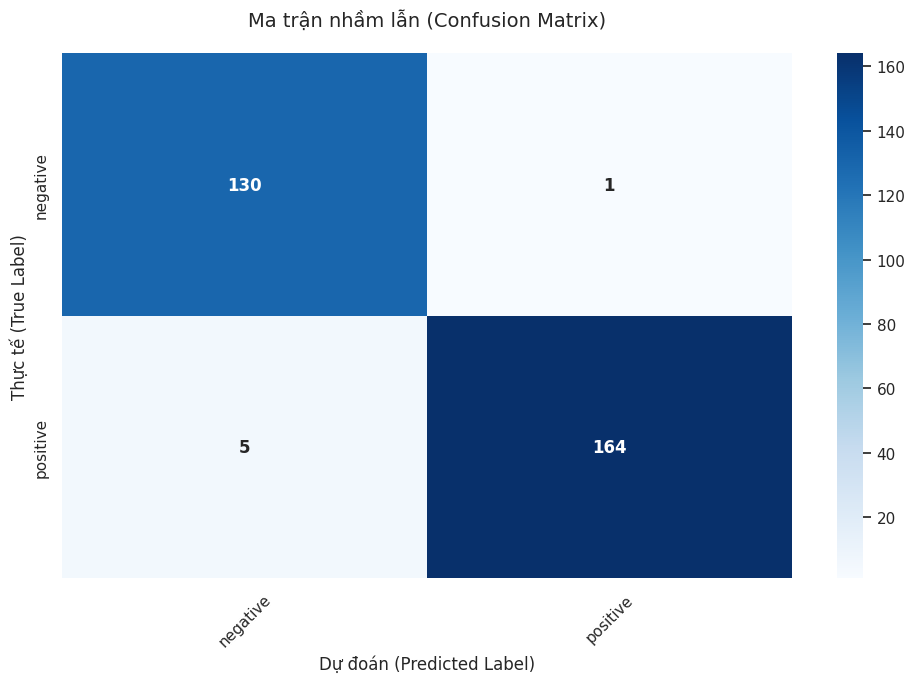


✅ CPU Latency: 2353.0122 ms

✅ GPU Latency: 22.9233 ms


Tokenizing:   0%|          | 0/1510 [00:00<?, ? examples/s]

Phân phối của AIVIVN-2019 TEST SET: {'Long': 876, 'Short': 321, 'Medium': 313}


✅ Overall Accuracy: 0.8200 (82.00%)
------------------------------------------------------------
✅ Macro F1 Score: 0.8200
------------------------------------------------------------

📊 KẾT QUẢ ĐÁNH GIÁ: [300 SAMPLE AIVIVN-2019 TEST SET]
📋 Classification Report:
              precision    recall  f1-score   support

    negative     0.7184    0.9615    0.8224       130
    positive     0.9603    0.7118    0.8176       170

    accuracy                         0.8200       300
   macro avg     0.8394    0.8367    0.8200       300
weighted avg     0.8555    0.8200    0.8196       300



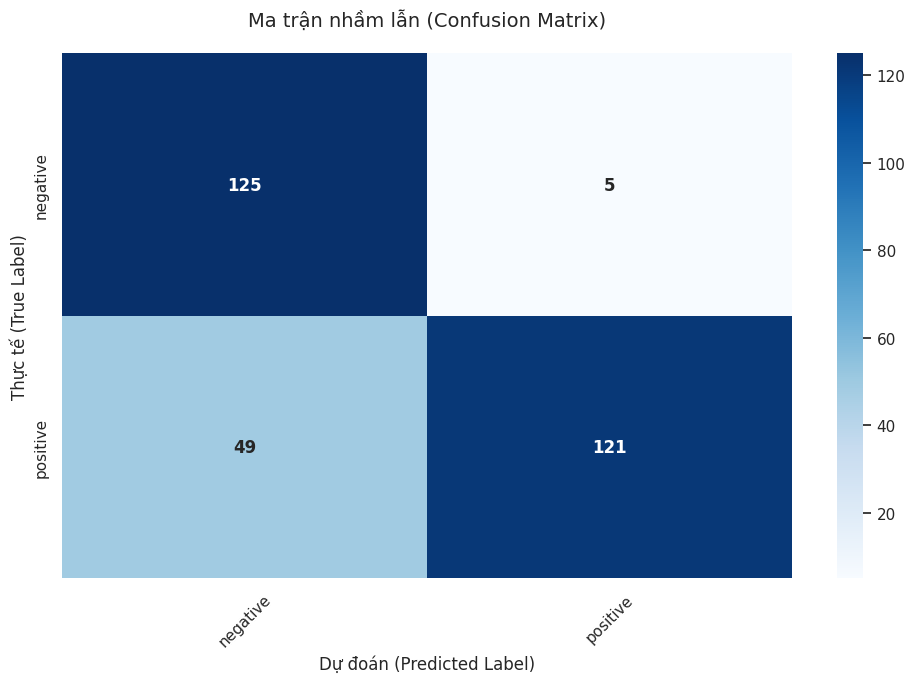

Tokenizing:   0%|          | 0/314 [00:00<?, ? examples/s]

Phân phối của CRAWL DATA SET: {'Long': 204, 'Medium': 70, 'Short': 40}


✅ Overall Accuracy: 0.8900 (89.00%)
------------------------------------------------------------
✅ Macro F1 Score: 0.8853
------------------------------------------------------------

📊 KẾT QUẢ ĐÁNH GIÁ: [300 SAMPLE CRAWL DATA SET]
📋 Classification Report:
              precision    recall  f1-score   support

    negative     0.8047    0.9279    0.8619       111
    positive     0.9535    0.8677    0.9086       189

    accuracy                         0.8900       300
   macro avg     0.8791    0.8978    0.8853       300
weighted avg     0.8984    0.8900    0.8913       300



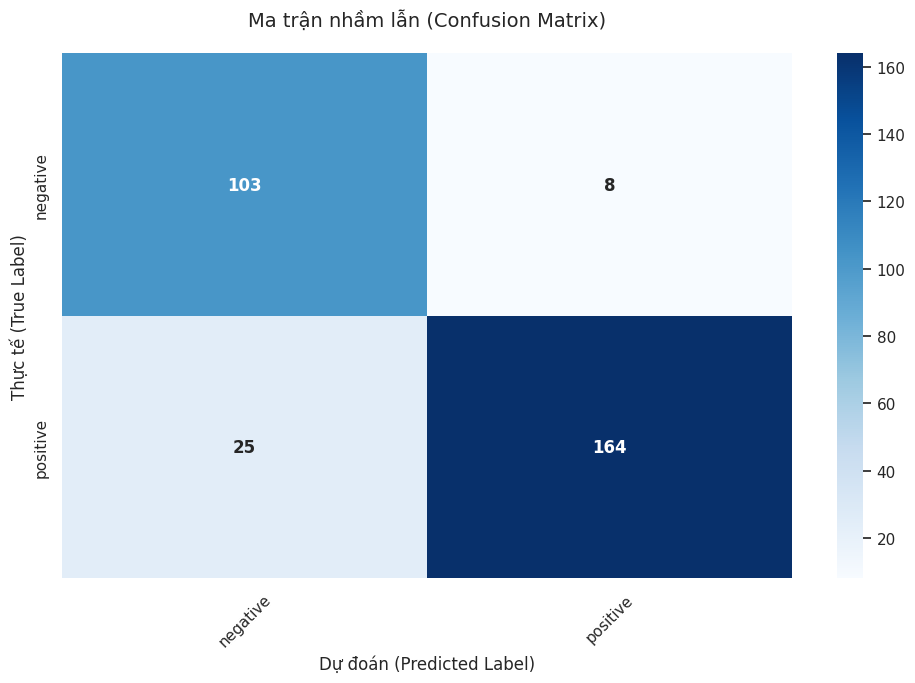

--- Domain Shift Analysis ---
Performance on UIT-VSFC Test Set (Original Domain):
  Accuracy: 0.9800
  Macro F1 Score: 0.9797

Performance on AIVIVN-2019 Test Set (New Domain):
  Accuracy: 0.8200
  Macro F1 Score: 0.8200

Performance on Crawl Data Test Set (New Domain):
  Accuracy: 0.8900
  Macro F1 Score: 0.8853

--- Quantitative Domain Shift between uit-vsfc and aivivn-2019 ---
  Accuracy Drop: 0.1600 (16.00%)
  Macro F1 Score Drop: 0.1598 (15.98%)

Observation (UIT-VSFC and AIVIVN-2019 ): There is a significant domain shift indicated by the substantial drop in performance.

--- Quantitative Domain Shift between uit-vsfc and crawl data ---
  Accuracy Drop: 0.0900 (9.00%)
  Macro F1 Score Drop: 0.0945 (9.45%)

Observation (UIT-VSFC and Crawl Data): There is a significant domain shift indicated by the substantial drop in performance.
✅ Logged: {'ID': 1, 'Model': 'vinai/phobert-base', 'Seed': 42, 'UIT-VSFC Accuracy': 0.98, 'UIT-VSFC Macro-F1': 0.9797, 'UIT-VSFC Std': 0.0023, 'AIVIVN-201

eval/accuracy,▁▆▆▄█
eval/f1,▁▆▆▅█
eval/loss,█▁▂▃▃
eval/runtime,█▅▂▁▄
eval/samples_per_second,▁▄▇█▄
eval/steps_per_second,▁▄▇█▄
test/accuracy,█▁▄
test/f1,█▁▄
test/loss,▁█▄
test/runtime,██▁
+7,...



--- Training with seed=0 ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Phân tích kết quả theo độ dài văn bản.
Phân phối của UIT-VSFC TEST SET: {'Short': 683, 'Long': 419, 'Medium': 408}


✅ In ra accuracy và macro-f1 uit-vsfc test set.
✅ Overall Accuracy: 0.9800 (98.00%)
------------------------------------------------------------
✅ Macro F1 Score: 0.9800
------------------------------------------------------------
✅ In ra report và confusion matrix trên 300 mẫu uit-vsfc test set.

📊 KẾT QUẢ ĐÁNH GIÁ: [300 SAMPLE UIT-VSFC TEST SET]
📋 Classification Report:
              precision    recall  f1-score   support

    negative     0.9658    0.9930    0.9792       142
    positive     0.9935    0.9684    0.9808       158

    accuracy                         0.9800       300
   macro avg     0.9796    0.9807    0.9800       300
weighted avg     0.9804    0.9800    0.9800       300



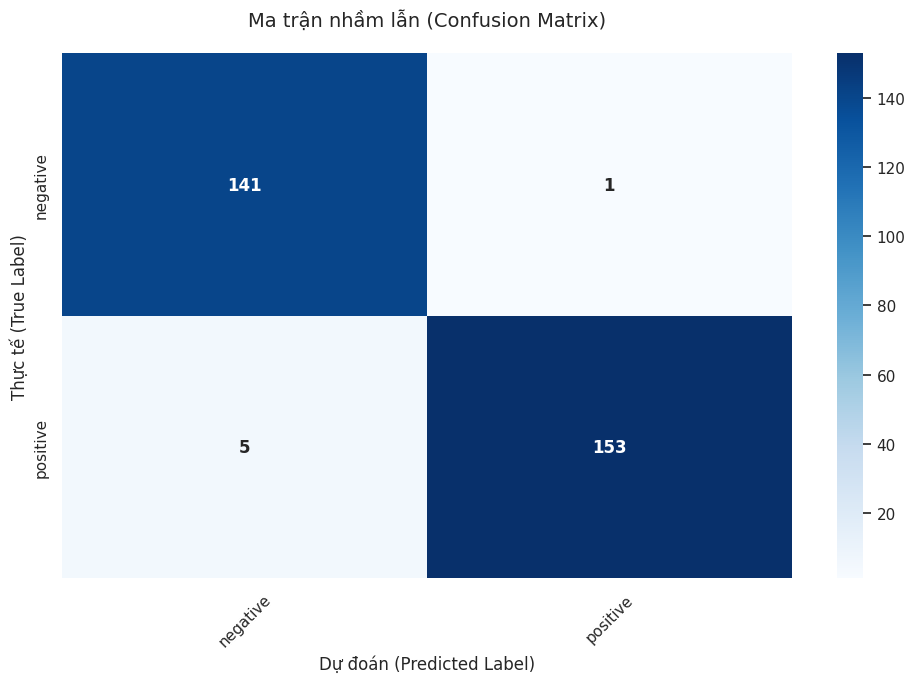


✅ CPU Latency: 2173.3733 ms

✅ GPU Latency: 22.7372 ms


Tokenizing:   0%|          | 0/1510 [00:00<?, ? examples/s]

Phân phối của AIVIVN-2019 TEST SET: {'Long': 869, 'Medium': 337, 'Short': 304}


✅ Overall Accuracy: 0.8233 (82.33%)
------------------------------------------------------------
✅ Macro F1 Score: 0.8232
------------------------------------------------------------

📊 KẾT QUẢ ĐÁNH GIÁ: [300 SAMPLE AIVIVN-2019 TEST SET]
📋 Classification Report:
              precision    recall  f1-score   support

    negative     0.7314    0.9552    0.8285       134
    positive     0.9520    0.7169    0.8179       166

    accuracy                         0.8233       300
   macro avg     0.8417    0.8360    0.8232       300
weighted avg     0.8535    0.8233    0.8226       300



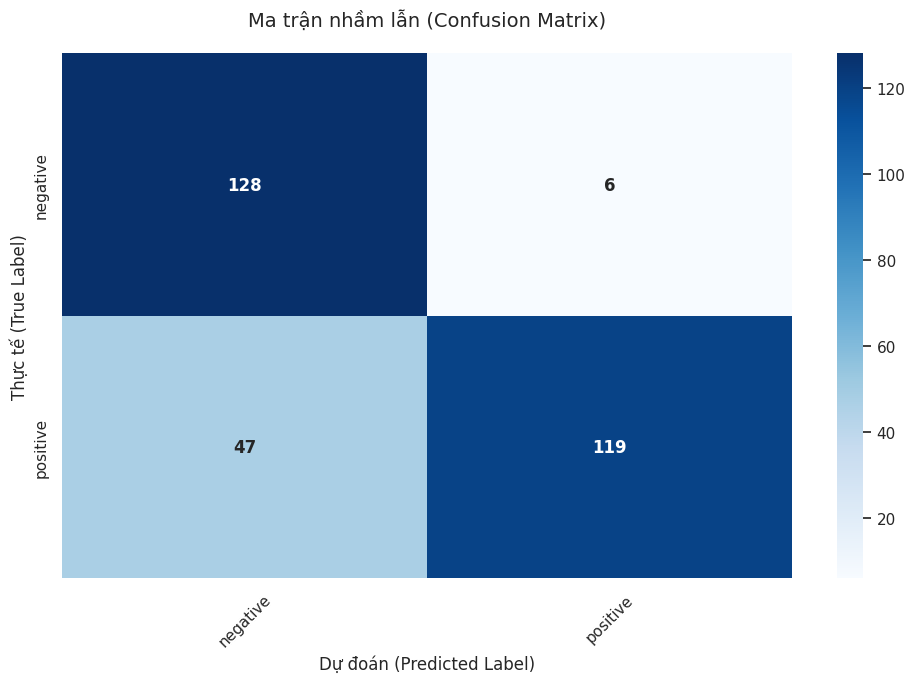

Tokenizing:   0%|          | 0/314 [00:00<?, ? examples/s]

Phân phối của CRAWL DATA SET: {'Long': 204, 'Medium': 70, 'Short': 40}


✅ Overall Accuracy: 0.8867 (88.67%)
------------------------------------------------------------
✅ Macro F1 Score: 0.8793
------------------------------------------------------------

📊 KẾT QUẢ ĐÁNH GIÁ: [300 SAMPLE CRAWL DATA SET]
📋 Classification Report:
              precision    recall  f1-score   support

    negative     0.8205    0.8807    0.8496       109
    positive     0.9290    0.8901    0.9091       191

    accuracy                         0.8867       300
   macro avg     0.8747    0.8854    0.8793       300
weighted avg     0.8896    0.8867    0.8875       300



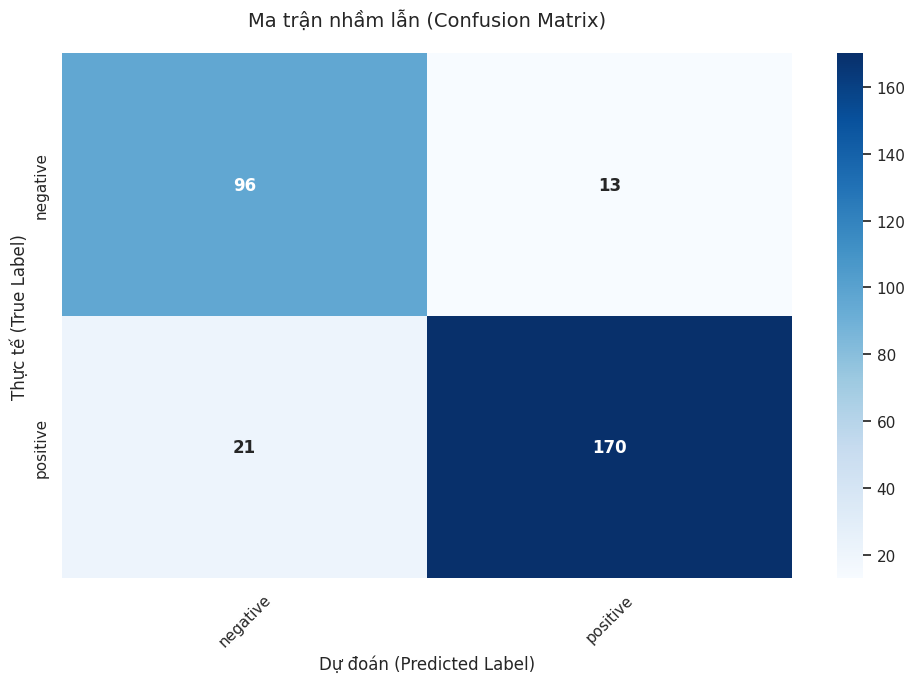

--- Domain Shift Analysis ---
Performance on UIT-VSFC Test Set (Original Domain):
  Accuracy: 0.9800
  Macro F1 Score: 0.9800

Performance on AIVIVN-2019 Test Set (New Domain):
  Accuracy: 0.8233
  Macro F1 Score: 0.8232

Performance on Crawl Data Test Set (New Domain):
  Accuracy: 0.8867
  Macro F1 Score: 0.8793

--- Quantitative Domain Shift between uit-vsfc and aivivn-2019 ---
  Accuracy Drop: 0.1567 (15.67%)
  Macro F1 Score Drop: 0.1568 (15.68%)

Observation (UIT-VSFC and AIVIVN-2019 ): There is a significant domain shift indicated by the substantial drop in performance.

--- Quantitative Domain Shift between uit-vsfc and crawl data ---
  Accuracy Drop: 0.0933 (9.33%)
  Macro F1 Score Drop: 0.1006 (10.06%)

Observation (UIT-VSFC and Crawl Data): There is a significant domain shift indicated by the substantial drop in performance.
✅ Logged: {'ID': 2, 'Model': 'vinai/phobert-base', 'Seed': 0, 'UIT-VSFC Accuracy': 0.98, 'UIT-VSFC Macro-F1': 0.98, 'UIT-VSFC Std': 0.0008, 'AIVIVN-2019 

eval/accuracy,▁█▇▅▆
eval/f1,▁█▇▅▆
eval/loss,█▁▃▄▄
eval/runtime,▁▁▆█▂
eval/samples_per_second,██▃▁▆
eval/steps_per_second,██▃▁▆
test/accuracy,█▁▄
test/f1,█▁▃
test/loss,▁█▄
test/runtime,██▁
+7,...



--- Training with seed=1 ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Phân tích kết quả theo độ dài văn bản.
Phân phối của UIT-VSFC TEST SET: {'Short': 683, 'Long': 419, 'Medium': 408}


✅ In ra accuracy và macro-f1 uit-vsfc test set.
✅ Overall Accuracy: 0.9833 (98.33%)
------------------------------------------------------------
✅ Macro F1 Score: 0.9833
------------------------------------------------------------
✅ In ra report và confusion matrix trên 300 mẫu uit-vsfc test set.

📊 KẾT QUẢ ĐÁNH GIÁ: [300 SAMPLE UIT-VSFC TEST SET]
📋 Classification Report:
              precision    recall  f1-score   support

    negative     0.9786    0.9856    0.9821       139
    positive     0.9875    0.9814    0.9844       161

    accuracy                         0.9833       300
   macro avg     0.9830    0.9835    0.9833       300
weighted avg     0.9834    0.9833    0.9833       300



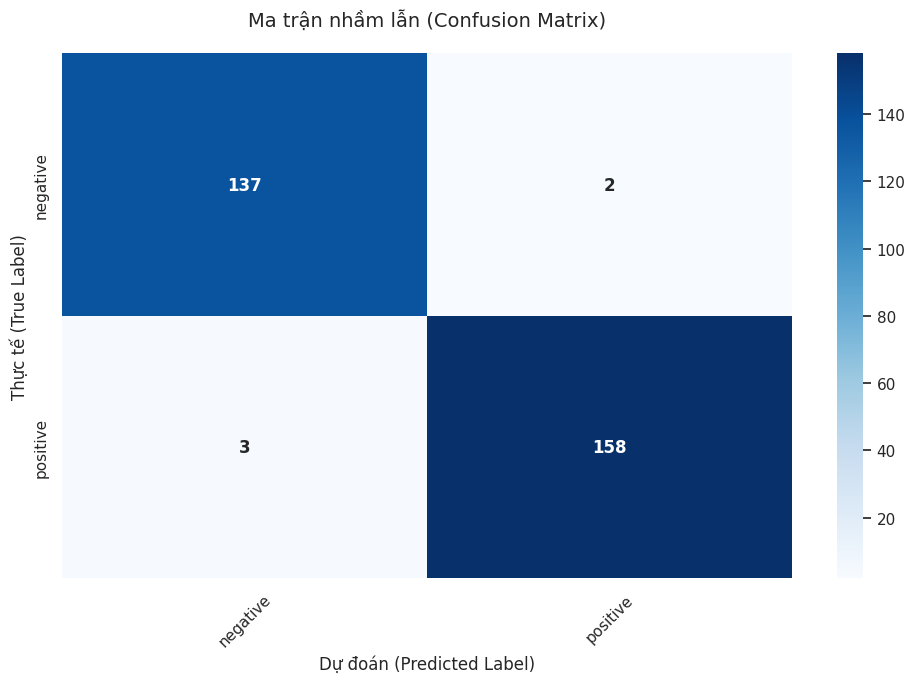


✅ CPU Latency: 2173.2506 ms

✅ GPU Latency: 20.0694 ms


Tokenizing:   0%|          | 0/1510 [00:00<?, ? examples/s]

Phân phối của AIVIVN-2019 TEST SET: {'Long': 864, 'Medium': 328, 'Short': 318}


✅ Overall Accuracy: 0.8533 (85.33%)
------------------------------------------------------------
✅ Macro F1 Score: 0.8501
------------------------------------------------------------

📊 KẾT QUẢ ĐÁNH GIÁ: [300 SAMPLE AIVIVN-2019 TEST SET]
📋 Classification Report:
              precision    recall  f1-score   support

    negative     0.7260    0.9636    0.8281       110
    positive     0.9740    0.7895    0.8721       190

    accuracy                         0.8533       300
   macro avg     0.8500    0.8766    0.8501       300
weighted avg     0.8831    0.8533    0.8560       300



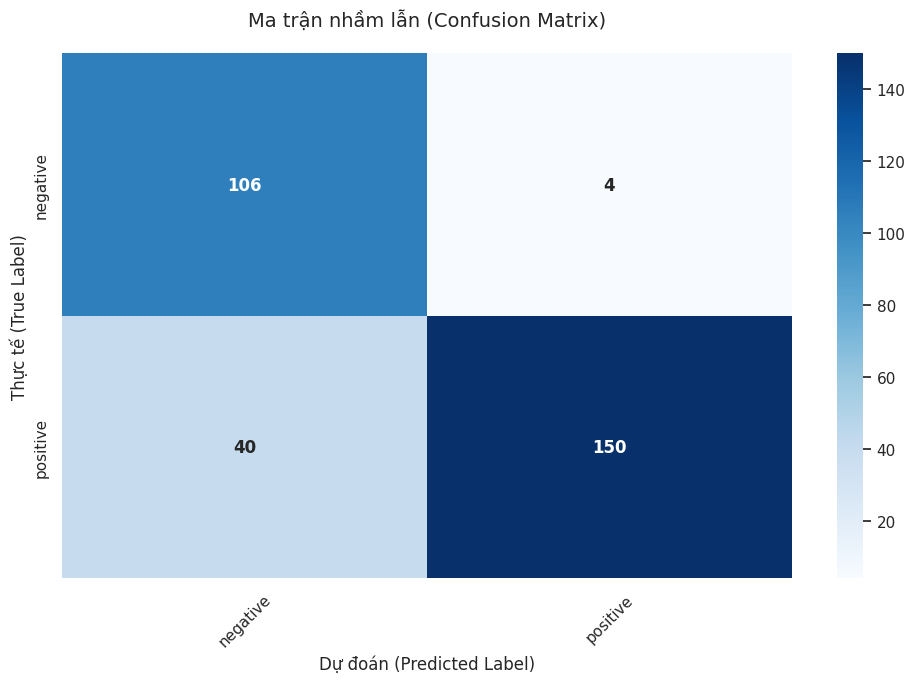

Tokenizing:   0%|          | 0/314 [00:00<?, ? examples/s]

Phân phối của CRAWL DATA SET: {'Long': 204, 'Medium': 70, 'Short': 40}


✅ Overall Accuracy: 0.8800 (88.00%)
------------------------------------------------------------
✅ Macro F1 Score: 0.8698
------------------------------------------------------------

📊 KẾT QUẢ ĐÁNH GIÁ: [300 SAMPLE CRAWL DATA SET]
📋 Classification Report:
              precision    recall  f1-score   support

    negative     0.8411    0.8257    0.8333       109
    positive     0.9016    0.9110    0.9062       191

    accuracy                         0.8800       300
   macro avg     0.8713    0.8683    0.8698       300
weighted avg     0.8796    0.8800    0.8798       300



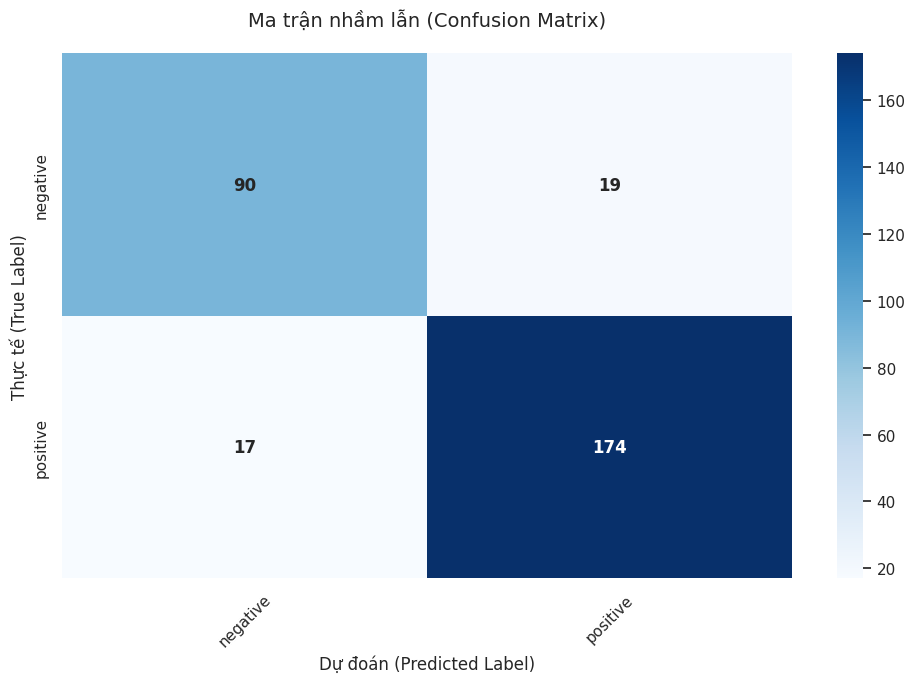

--- Domain Shift Analysis ---
Performance on UIT-VSFC Test Set (Original Domain):
  Accuracy: 0.9833
  Macro F1 Score: 0.9833

Performance on AIVIVN-2019 Test Set (New Domain):
  Accuracy: 0.8533
  Macro F1 Score: 0.8501

Performance on Crawl Data Test Set (New Domain):
  Accuracy: 0.8800
  Macro F1 Score: 0.8698

--- Quantitative Domain Shift between uit-vsfc and aivivn-2019 ---
  Accuracy Drop: 0.1300 (13.00%)
  Macro F1 Score Drop: 0.1331 (13.31%)

Observation (UIT-VSFC and AIVIVN-2019 ): There is a significant domain shift indicated by the substantial drop in performance.

--- Quantitative Domain Shift between uit-vsfc and crawl data ---
  Accuracy Drop: 0.1033 (10.33%)
  Macro F1 Score Drop: 0.1135 (11.35%)

Observation (UIT-VSFC and Crawl Data): There is a significant domain shift indicated by the substantial drop in performance.
✅ Logged: {'ID': 3, 'Model': 'vinai/phobert-base', 'Seed': 1, 'UIT-VSFC Accuracy': 0.9833, 'UIT-VSFC Macro-F1': 0.9833, 'UIT-VSFC Std': 0.0012, 'AIVIVN-

eval/accuracy,▁▇█▃▇
eval/f1,▁▇█▃▇
eval/loss,▇▁▄██
eval/runtime,▄▁▁▅█
eval/samples_per_second,▅██▄▁
eval/steps_per_second,▅██▄▁
test/accuracy,█▁▂
test/f1,█▁▂
test/loss,▁█▄
test/runtime,██▁
+7,...



--- Training with seed=123 ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Phân tích kết quả theo độ dài văn bản.
Phân phối của UIT-VSFC TEST SET: {'Short': 683, 'Long': 419, 'Medium': 408}


✅ In ra accuracy và macro-f1 uit-vsfc test set.
✅ Overall Accuracy: 0.9800 (98.00%)
------------------------------------------------------------
✅ Macro F1 Score: 0.9800
------------------------------------------------------------
✅ In ra report và confusion matrix trên 300 mẫu uit-vsfc test set.

📊 KẾT QUẢ ĐÁNH GIÁ: [300 SAMPLE UIT-VSFC TEST SET]
📋 Classification Report:
              precision    recall  f1-score   support

    negative     0.9726    0.9861    0.9793       144
    positive     0.9870    0.9744    0.9806       156

    accuracy                         0.9800       300
   macro avg     0.9798    0.9802    0.9800       300
weighted avg     0.9801    0.9800    0.9800       300



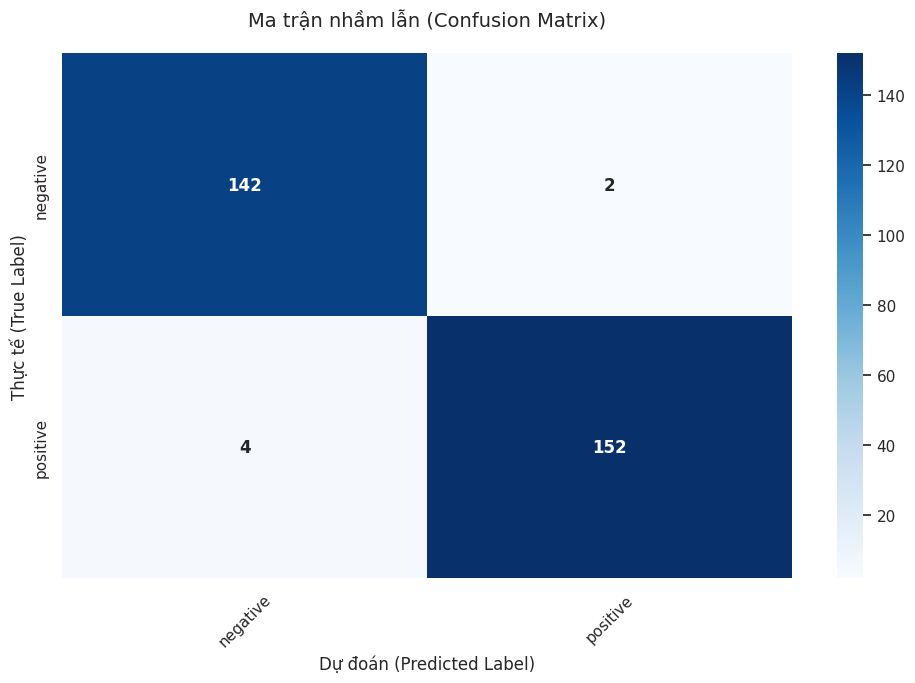


✅ CPU Latency: 2277.0141 ms

✅ GPU Latency: 24.7923 ms


Tokenizing:   0%|          | 0/1510 [00:00<?, ? examples/s]

Phân phối của AIVIVN-2019 TEST SET: {'Long': 870, 'Medium': 336, 'Short': 304}


✅ Overall Accuracy: 0.8333 (83.33%)
------------------------------------------------------------
✅ Macro F1 Score: 0.8326
------------------------------------------------------------

📊 KẾT QUẢ ĐÁNH GIÁ: [300 SAMPLE AIVIVN-2019 TEST SET]
📋 Classification Report:
              precision    recall  f1-score   support

    negative     0.7372    0.9274    0.8214       124
    positive     0.9375    0.7670    0.8438       176

    accuracy                         0.8333       300
   macro avg     0.8373    0.8472    0.8326       300
weighted avg     0.8547    0.8333    0.8345       300



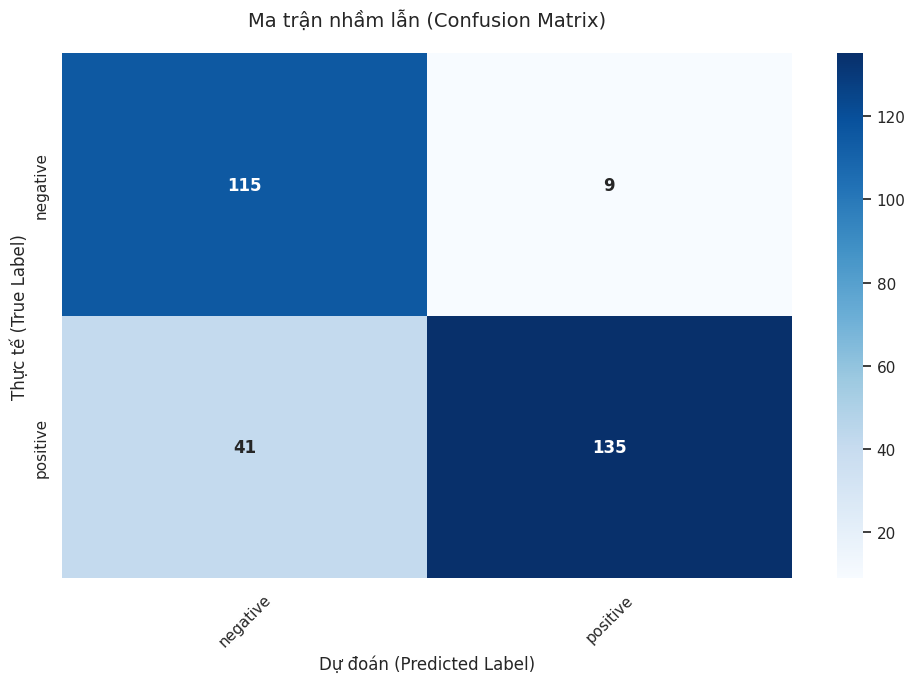

Tokenizing:   0%|          | 0/314 [00:00<?, ? examples/s]

Phân phối của CRAWL DATA SET: {'Long': 204, 'Medium': 70, 'Short': 40}


✅ Overall Accuracy: 0.8867 (88.67%)
------------------------------------------------------------
✅ Macro F1 Score: 0.8784
------------------------------------------------------------

📊 KẾT QUẢ ĐÁNH GIÁ: [300 SAMPLE CRAWL DATA SET]
📋 Classification Report:
              precision    recall  f1-score   support

    negative     0.8246    0.8704    0.8468       108
    positive     0.9247    0.8958    0.9101       192

    accuracy                         0.8867       300
   macro avg     0.8746    0.8831    0.8784       300
weighted avg     0.8887    0.8867    0.8873       300



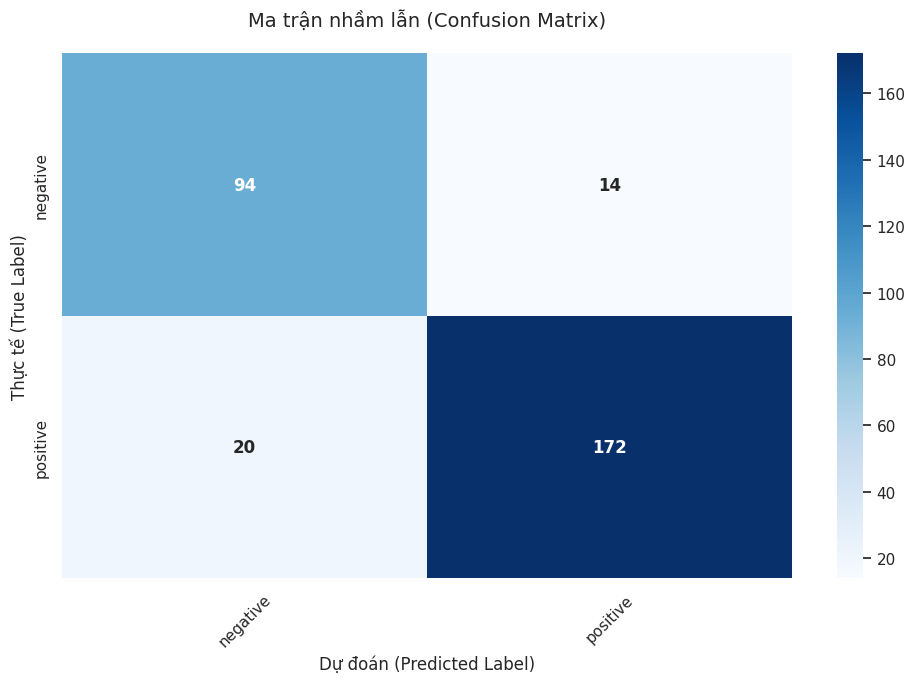

--- Domain Shift Analysis ---
Performance on UIT-VSFC Test Set (Original Domain):
  Accuracy: 0.9800
  Macro F1 Score: 0.9800

Performance on AIVIVN-2019 Test Set (New Domain):
  Accuracy: 0.8333
  Macro F1 Score: 0.8326

Performance on Crawl Data Test Set (New Domain):
  Accuracy: 0.8867
  Macro F1 Score: 0.8784

--- Quantitative Domain Shift between uit-vsfc and aivivn-2019 ---
  Accuracy Drop: 0.1467 (14.67%)
  Macro F1 Score Drop: 0.1474 (14.74%)

Observation (UIT-VSFC and AIVIVN-2019 ): There is a significant domain shift indicated by the substantial drop in performance.

--- Quantitative Domain Shift between uit-vsfc and crawl data ---
  Accuracy Drop: 0.0933 (9.33%)
  Macro F1 Score Drop: 0.1015 (10.15%)

Observation (UIT-VSFC and Crawl Data): There is a significant domain shift indicated by the substantial drop in performance.
✅ Logged: {'ID': 4, 'Model': 'vinai/phobert-base', 'Seed': 123, 'UIT-VSFC Accuracy': 0.98, 'UIT-VSFC Macro-F1': 0.98, 'UIT-VSFC Std': 0.0007, 'AIVIVN-201

eval/accuracy,▁█▄█▂
eval/f1,▁█▄█▂
eval/loss,█▁▃▄▆
eval/runtime,▁▂█▆▁
eval/samples_per_second,█▇▁▃█
eval/steps_per_second,█▇▁▃█
test/accuracy,█▁▄
test/f1,█▁▃
test/loss,▁█▅
test/runtime,██▁
+7,...



--- Training with seed=2026 ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Phân tích kết quả theo độ dài văn bản.
Phân phối của UIT-VSFC TEST SET: {'Short': 683, 'Long': 419, 'Medium': 408}


✅ In ra accuracy và macro-f1 uit-vsfc test set.
✅ Overall Accuracy: 0.9867 (98.67%)
------------------------------------------------------------
✅ Macro F1 Score: 0.9866
------------------------------------------------------------
✅ In ra report và confusion matrix trên 300 mẫu uit-vsfc test set.

📊 KẾT QUẢ ĐÁNH GIÁ: [300 SAMPLE UIT-VSFC TEST SET]
📋 Classification Report:
              precision    recall  f1-score   support

    negative     0.9854    0.9854    0.9854       137
    positive     0.9877    0.9877    0.9877       163

    accuracy                         0.9867       300
   macro avg     0.9866    0.9866    0.9866       300
weighted avg     0.9867    0.9867    0.9867       300



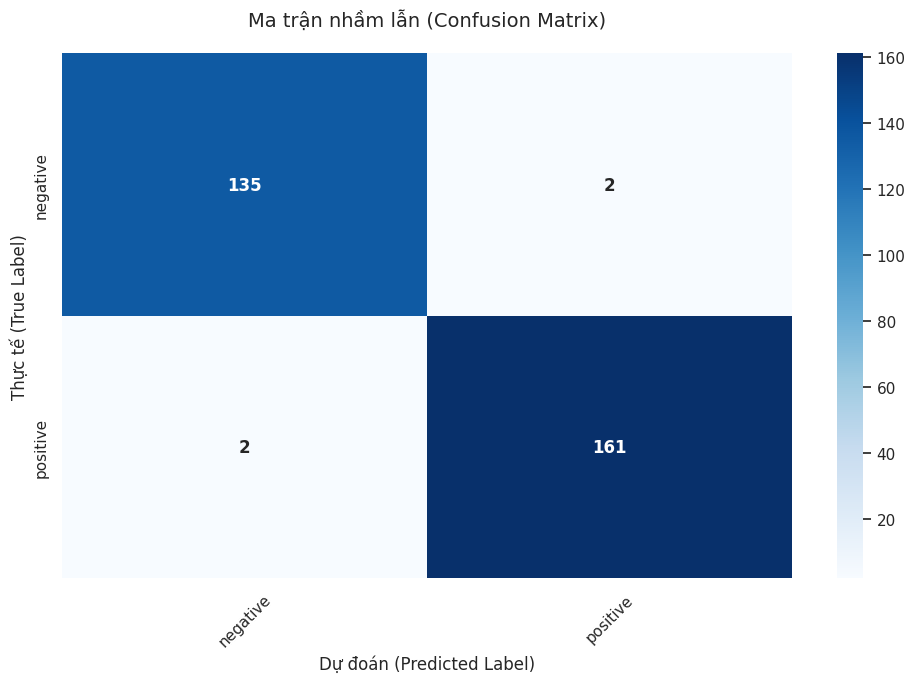


✅ CPU Latency: 2161.5549 ms

✅ GPU Latency: 21.2336 ms


Tokenizing:   0%|          | 0/1510 [00:00<?, ? examples/s]

Phân phối của AIVIVN-2019 TEST SET: {'Long': 879, 'Medium': 327, 'Short': 304}


✅ Overall Accuracy: 0.8567 (85.67%)
------------------------------------------------------------
✅ Macro F1 Score: 0.8555
------------------------------------------------------------

📊 KẾT QUẢ ĐÁNH GIÁ: [300 SAMPLE AIVIVN-2019 TEST SET]
📋 Classification Report:
              precision    recall  f1-score   support

    negative     0.7616    0.9426    0.8425       122
    positive     0.9530    0.7978    0.8685       178

    accuracy                         0.8567       300
   macro avg     0.8573    0.8702    0.8555       300
weighted avg     0.8752    0.8567    0.8579       300



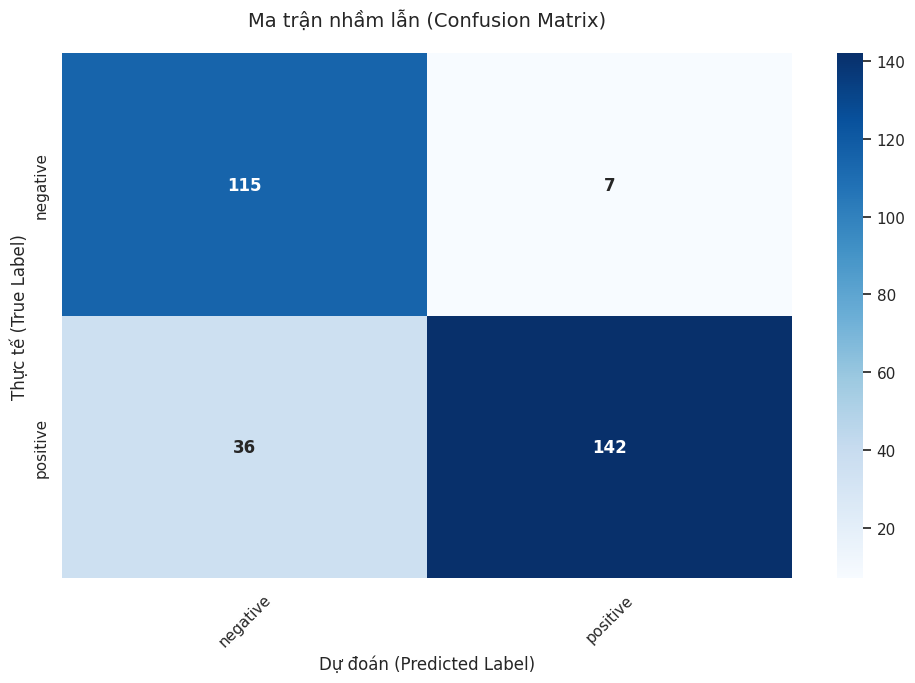

Tokenizing:   0%|          | 0/314 [00:00<?, ? examples/s]

Phân phối của CRAWL DATA SET: {'Long': 204, 'Medium': 70, 'Short': 40}


✅ Overall Accuracy: 0.8900 (89.00%)
------------------------------------------------------------
✅ Macro F1 Score: 0.8827
------------------------------------------------------------

📊 KẾT QUẢ ĐÁNH GIÁ: [300 SAMPLE CRAWL DATA SET]
📋 Classification Report:
              precision    recall  f1-score   support

    negative     0.8205    0.8889    0.8533       108
    positive     0.9344    0.8906    0.9120       192

    accuracy                         0.8900       300
   macro avg     0.8775    0.8898    0.8827       300
weighted avg     0.8934    0.8900    0.8909       300



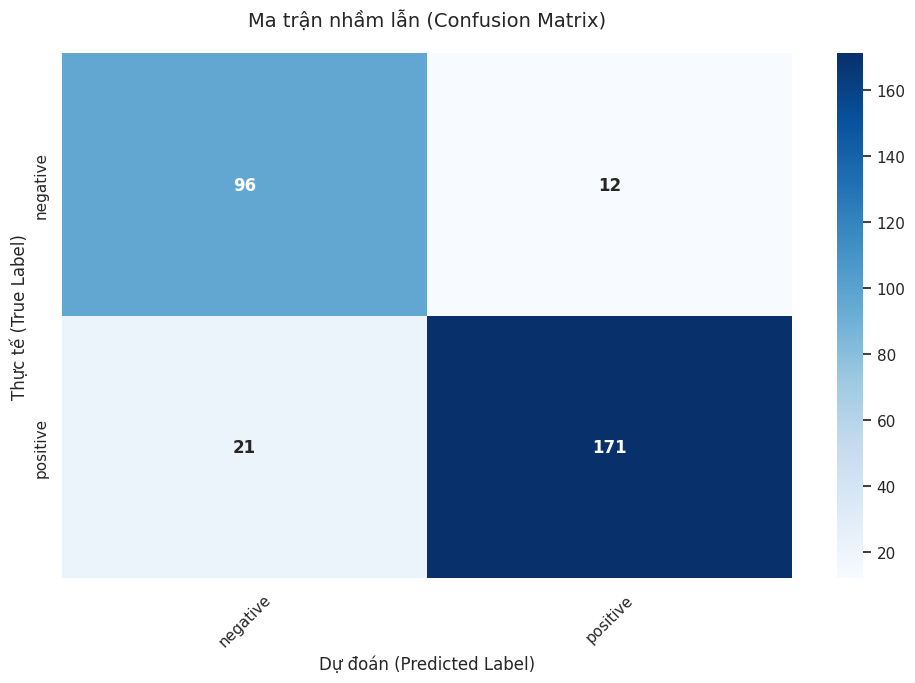

--- Domain Shift Analysis ---
Performance on UIT-VSFC Test Set (Original Domain):
  Accuracy: 0.9867
  Macro F1 Score: 0.9866

Performance on AIVIVN-2019 Test Set (New Domain):
  Accuracy: 0.8567
  Macro F1 Score: 0.8555

Performance on Crawl Data Test Set (New Domain):
  Accuracy: 0.8900
  Macro F1 Score: 0.8827

--- Quantitative Domain Shift between uit-vsfc and aivivn-2019 ---
  Accuracy Drop: 0.1300 (13.00%)
  Macro F1 Score Drop: 0.1311 (13.11%)

Observation (UIT-VSFC and AIVIVN-2019 ): There is a significant domain shift indicated by the substantial drop in performance.

--- Quantitative Domain Shift between uit-vsfc and crawl data ---
  Accuracy Drop: 0.0967 (9.67%)
  Macro F1 Score Drop: 0.1039 (10.39%)

Observation (UIT-VSFC and Crawl Data): There is a significant domain shift indicated by the substantial drop in performance.
✅ Logged: {'ID': 5, 'Model': 'vinai/phobert-base', 'Seed': 2026, 'UIT-VSFC Accuracy': 0.9867, 'UIT-VSFC Macro-F1': 0.9866, 'UIT-VSFC Std': 0.0012, 'AIVIV

eval/accuracy,▁▅█▆▆
eval/f1,▁▅█▆▆
eval/loss,█▁▁▃▄
eval/runtime,▃█▂█▁
eval/samples_per_second,▆▁▇▁█
eval/steps_per_second,▆▁▇▁█
test/accuracy,█▁▃
test/f1,█▁▃
test/loss,▁█▄
test/runtime,██▁
+7,...



✅ Best seed: 2026 | Macro-F1: 0.9866


In [ ]:
import copy  # cần cho việc snapshot state_dict an toàn giữa các seed

seeds = [42, 0, 1, 123, 2026]
results = []  # FIX #2: track kết quả từng seed để chọn best

for seed in seeds:
    print(f"\n--- Training with seed={seed} ---")

    set_seed(seed)
    set_cuda_seed(seed)

    model = build_phobert_classifier()

    # FIX #2: output_dir riêng cho từng seed, tránh checkpoint đè lẫn nhau
    seed_output_dir = f"./phobert_vsa/seed_{seed}"

    if wandb.api.api_key is None:
        wandb.login()

    trainer = train_model(
        model,
        train_enc,
        valid_enc,
        tokenizer,
        output_dir=seed_output_dir,          # <-- truyền output_dir riêng
        patience=3,
        report_to="wandb",
        project_name="vietnamese-sentiment-analysis-phobert-model-log",
        run_name=f"phobert_run_seed_{seed}",
    )

    label_names = get_label_names(trainer)

    print("=" * 50)
    print("✅ Phân tích kết quả theo độ dài văn bản.")
    test_df = add_length_category(test_df, LOW_THRESHOLD, HIGH_THRESHOLD,
                                  df_name='UIT-VSFC TEST SET')

    predicted_labels_uit_vsfc = predict(trainer, test_enc)
    test_df["pred_label"] = predicted_labels_uit_vsfc

    test_sample_df = test_df.copy().sample(n=300, random_state=seed).reset_index(drop=True)

    print("=" * 50)
    print("✅ In ra accuracy và macro-f1 uit-vsfc test set.")
    evaluate(test_sample_df, label_names=label_names, dataset_name="UIT-VSFC TEST SET")

    print("=" * 50)
    print("✅ In ra report và confusion matrix trên 300 mẫu uit-vsfc test set.")
    report(test_sample_df, label_names=label_names, dataset_name="300 sample UIT-VSFC TEST SET")

    print("=" * 50)
    texts = test_df["text"].iloc[:10].tolist()
    cpu_latency = measure_cpu_latency(model, tokenizer, texts)
    gpu_latency = measure_gpu_latency(model, tokenizer, texts)
    print(f"\n✅ CPU Latency: {cpu_latency} ms")
    print(f"\n✅ GPU Latency: {gpu_latency} ms" if gpu_latency else "⚠️ GPU Latency: N/A")

    aivivn_sample_df = sample_dataframe(sample_df=test_df_aivivn, n=len(test_df), seed=seed).reset_index(drop=True)
    test_dataset_hf = to_hf_dataset(aivivn_sample_df)
    X_sample = tokenize_dataset(test_dataset_hf, tokenizer)

    aivivn_sample_df = add_length_category(aivivn_sample_df, LOW_THRESHOLD, HIGH_THRESHOLD,
                                  df_name='AIVIVN-2019 TEST SET')
    predicted_labels_aivivn = predict(trainer, X_sample)
    aivivn_sample_df["pred_label"] = predicted_labels_aivivn
    aivivn_new_sample_df = aivivn_sample_df.copy().sample(n=300, random_state=seed).reset_index(drop=True)

    evaluate(aivivn_new_sample_df, label_names=label_names, dataset_name="AIVIVN-2019 TEST SET")
    report(aivivn_new_sample_df, label_names=label_names, dataset_name="300 sample AIVIVN-2019 TEST SET")
    preview_predictions_aivivn(aivivn_new_sample_df, n=10, random_state=seed)

    crawl_sample_df = crawl_df.copy()
    crawl_hf_dataset = crawl_to_hf_dataset(crawl_sample_df)
    crawl_test_enc_sample = tokenize_dataset(crawl_hf_dataset, tokenizer)

    crawl_sample_df = add_length_category(crawl_sample_df, LOW_THRESHOLD, HIGH_THRESHOLD,
                                  df_name='CRAWL DATA SET')
    predicted_labels_crawl = predict(trainer, crawl_test_enc_sample)
    crawl_sample_df["pred_label"] = predicted_labels_crawl
    crawl_new_sample_df = crawl_sample_df.copy().sample(n=300, random_state=seed).reset_index(drop=True)

    evaluate(crawl_new_sample_df, label_names=label_names, dataset_name="CRAWL DATA SET")
    report(crawl_new_sample_df, label_names=label_names, dataset_name="300 sample CRAWL DATA SET")
    preview_predictions_crawl(crawl_new_sample_df, n=10, random_state=seed)

    domain_shift_analysis(
        test_sample_df=test_sample_df,
        aivivn_sample_df=aivivn_new_sample_df,
        crawl_sample_df=crawl_new_sample_df
    )

    log_result(
        model_name=model.config._name_or_path, seed=seed,
        test_sample_df=test_sample_df, aivivn_sample_df=aivivn_new_sample_df,
        crawl_sample_df=crawl_new_sample_df,
        cpu_latency=cpu_latency, gpu_latency=gpu_latency
    )
    log_result_domain_shift(
        model_name=model.config._name_or_path, seed=seed,
        test_sample_df=test_sample_df, aivivn_sample_df=aivivn_new_sample_df,
        crawl_sample_df=crawl_new_sample_df
    )

    print("\n✅ Thử với một câu.")
    predict_sentence("Giảng viên truyền cảm hứng.")

    # FIX #1 + #2: lưu macro-F1 và snapshot trọng số (đưa về CPU để đỡ tốn VRAM)
    uit_vsfc_macro_f1 = round(float(f1_score(
        test_sample_df['label'].astype(int).values,
        test_sample_df['pred_label'].astype(int).values,
        average='macro'
    )), 4)

    results.append({
        'seed': seed,
        'macro_f1': uit_vsfc_macro_f1,
        'model_state': {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
    })

    print(f'\n✅ Kết thúc train seed {seed} | macro-F1 = {uit_vsfc_macro_f1}')

    # FIX #4: đóng wandb run hiện tại trước khi sang seed kế tiếp
    wandb.finish()

    # dọn bộ nhớ GPU giữa các seed
    del model, trainer
    torch.cuda.empty_cache()

# ── Chọn seed tốt nhất theo macro-F1 ────────────────────────────
best = max(results, key=lambda x: x['macro_f1'])
print(f'\n✅ Best seed: {best["seed"]} | Macro-F1: {best["macro_f1"]}')

In [ ]:
# Xem CSV

print("\n--- Training Log ---")
df_log_training = pd.read_csv(LOG_TRAINING_FILE)
display(df_log_training)
print("\n✅ Displayed training log.")

print("\n==============================")

print("\n--- Domain Shift Log ---")
df_log_domain_shift = pd.read_csv(LOG_DOMAIN_SHIFT_FILE)
display(df_log_domain_shift)
print("\n✅ Displayed domain shift log.")






--- Training Log ---


,ID,Model,Seed,UIT-VSFC Accuracy,UIT-VSFC Macro-F1,UIT-VSFC Std,AIVIVN-2019 Accuracy,AIVIVN-2019 Macro-F1,AIVIVN-2019 Std,CRAWL Accuracy,...,GPU Latency,Short (UIT-VSFC Test) F1,Medium (UIT-VSFC Test) F1,Long (UIT-VSFC Test) F1,Short (AIVIVN-2019 Test) F1,Medium (AIVIVN-2019 Test) F1,Long (AIVIVN-2019 Test) F1,Short (CRAWL Test) F1,Medium (CRAWL Test) F1,Long (CRAWL Test) F1
0,1,vinai/phobert-base,42,0.9800,0.9797,0.0023,0.8200,0.8200,0.0024,0.8900,...,22.9233 ms,0.9833,0.9885,0.9515,0.8533,0.7609,0.8240,0.8091,0.8829,0.8918
1,2,vinai/phobert-base,0,0.9800,0.9800,0.0008,0.8233,0.8232,0.0053,0.8867,...,22.7372 ms,0.9834,0.9663,0.9848,0.7821,0.7894,0.8482,0.8120,0.8961,0.8801
2,3,vinai/phobert-base,1,0.9833,0.9833,0.0012,0.8533,0.8501,0.0220,0.8800,...,20.0694 ms,1.0000,0.9878,0.9418,0.8152,0.8687,0.8418,0.8405,0.8999,0.8606
3,4,vinai/phobert-base,123,0.9800,0.9800,0.0007,0.8333,0.8326,0.0112,0.8867,...,24.7923 ms,0.9818,0.9775,0.9758,0.7917,0.8387,0.8424,0.8274,0.9138,0.8724
4,5,vinai/phobert-base,2026,0.9867,0.9866,0.0012,0.8567,0.8555,0.0130,0.8900,...,21.2336 ms,1.0000,0.9744,0.9720,0.7925,0.8691,0.8669,0.8120,0.8829,0.8889



✅ Displayed training log.


--- Domain Shift Log ---


,ID,Model,Seed,In-domain Accuracy,Out-of-domain Accuracy,Wild-test Accuracy,In-domain F1,Out-of-domain F1,Wild-test F1,Accuracy Drop(In-domain F1 - Out-of-domain F1) (%),Accuracy Drop(In-domain F1 - Wild-test F1) (%),F1 Score Drop(In-domain F1 - Out-of-domain F1) (%),F1 Score Drop(In-domain F1 - Wild-test F1) (%),Lỗi chính
0,1,vinai/phobert-base,42,0.9800,0.8200,0.8900,0.9797,0.8200,0.8853,16.00 %,9.00 %,15.97 %,9.44 %,NaN
1,2,vinai/phobert-base,0,0.9800,0.8233,0.8867,0.9800,0.8232,0.8793,15.67 %,9.33 %,15.68 %,10.07 %,NaN
2,3,vinai/phobert-base,1,0.9833,0.8533,0.8800,0.9833,0.8501,0.8698,13.00 %,10.33 %,13.32 %,11.35 %,NaN
3,4,vinai/phobert-base,123,0.9800,0.8333,0.8867,0.9800,0.8326,0.8784,14.67 %,9.33 %,14.74 %,10.16 %,NaN
4,5,vinai/phobert-base,2026,0.9867,0.8567,0.8900,0.9866,0.8555,0.8827,13.00 %,9.67 %,13.11 %,10.39 %,NaN



✅ Displayed domain shift log.


In [ ]:
#wandb.finish()

#14. Lưu model

In [ ]:
import json
import os

SAVE_DIR = '/content/models/phobert'
os.makedirs(SAVE_DIR, exist_ok=True)

# Dựng lại kiến trúc rồi nạp trọng số của seed tốt nhất
best_model = build_phobert_classifier()
best_model.load_state_dict(best['model_state'])
best_model.eval()

# FIX: gán lại biến toàn cục `model` = best_model ...
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model.to(device)
model = best_model


# save_pretrained() tự tạo config.json (config kiến trúc HF) + model weights
best_model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# Lưu metadata riêng — ĐẶT TÊN KHÁC "config.json" để không đè lên
# config.json mà save_pretrained() vừa tạo ở trên
inference_config = {
    "best_seed": best['seed'],
    "best_macro_f1": best['macro_f1'],
    "max_len": MAX_LEN,
    "num_classes": 2,
    "label_map_inv": {"0": "negative", "1": "positive"},
    "segmenter": "VnCoreNLP",
    "preprocessing_order": ["normalize_text", "segment_text", "tokenizer(...)"],
}
with open(f'{SAVE_DIR}/inference_config.json', 'w', encoding='utf-8') as f:
    json.dump(inference_config, f, indent=2, ensure_ascii=False)

print(f'✅ Đã lưu PhoBERT (seed={best["seed"]}, macro-F1={best["macro_f1"]}) vào {SAVE_DIR}')
print(f'✅ Đã gán model = best_model — có thể gọi predict_sentence(...) an toàn ngay sau đây.')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Đã lưu PhoBERT (seed=2026, macro-F1=0.9866) vào /content/models/phobert
✅ Đã gán model = best_model — có thể gọi predict_sentence(...) an toàn ngay sau đây.


In [ ]:
from google.colab import files
import shutil

#shutil.make_archive('/content/phobert_model', 'zip', SAVE_DIR)
#files.download('/content/phobert_model.zip')

# Thử Nghiệm

In [ ]:
'''
# seeds = [42, 0, 1, 123, 2026]
seed = 42

# Ensure wandb login is handled before the training loop
if wandb.api.api_key is None:
    wandb.login()

print(f"\n--- Training with seed={seed} ---")

# Fix seed
set_seed(seed)
set_cuda_seed(seed)

# Build model
model = build_phobert_classifier()

# Train model
trainer = train_model(
    model,
    train_enc,
    valid_enc,
    tokenizer,
    patience=3,
    report_to="wandb",
    project_name="vietnamese-sentiment-analysis-phobert-model-log",
    run_name=f"phobert_run_seed_{seed}",
)

'''

'\n# seeds = [42, 0, 1, 123, 2026]\nseed = 42\n\n# Ensure wandb login is handled before the training loop\nif wandb.api.api_key is None:\n    wandb.login()\n\nprint(f"\n--- Training with seed={seed} ---")\n\n# Fix seed\nset_seed(seed)\nset_cuda_seed(seed)\n\n# Build model\nmodel = build_phobert_classifier()\n\n# Train model\ntrainer = train_model(\n    model,\n    train_enc,\n    valid_enc,\n    tokenizer,\n    patience=3,\n    report_to="wandb",\n    project_name="vietnamese-sentiment-analysis-phobert-model-log",\n    run_name=f"phobert_run_seed_{seed}",\n)\n\n'

In [ ]:
'''
label_names = get_label_names(trainer)

# ── UIT-VSFC test set ────────────────────────────────────────────────────────

print("=" * 50)
print("✅ Phân tích kết quả theo độ dài văn bản.")

test_df = add_length_category(
    test_df,
    LOW_THRESHOLD,
    HIGH_THRESHOLD,
    df_name="UIT-VSFC TEST SET",
)

predicted_labels_uit_vsfc = predict(trainer, test_enc)
test_df["pred_label"] = predicted_labels_uit_vsfc

test_sample_df = (
    test_df.copy()
    .sample(n=300, random_state=seed)
    .reset_index(drop=True)
)

print("=" * 50)
print("✅ In ra accuracy và macro-f1 uit-vsfc test set.")
evaluate(test_sample_df, label_names=label_names, dataset_name="UIT-VSFC TEST SET")

print("=" * 50)
print("✅ In ra report và confusion matrix trên 300 mẫu uit-vsfc test set.")
report(test_sample_df, label_names=label_names, dataset_name="300 sample UIT-VSFC TEST SET")

# ── Latency ───────────────────────────────────────────────────────────────────

print("=" * 50)
print("✅ In ra latency.")
print("=" * 50)

texts = test_df["text"].iloc[:10].tolist()

cpu_latency = measure_cpu_latency(model, tokenizer, texts)
print(f"\n✅ CPU Latency: {cpu_latency} ms")

gpu_latency = measure_gpu_latency(model, tokenizer, texts)
print(
    f"\n✅ GPU Latency: {gpu_latency} ms"
    if gpu_latency
    else "⚠️ GPU Latency: N/A"
)
print("=" * 50)

# ── AIVIVN-2019 test set ──────────────────────────────────────────────────────

aivivn_sample_df = (
    sample_dataframe(sample_df=test_df_aivivn, n=len(test_df), seed=seed)
    .reset_index(drop=True)
)

test_dataset_hf = to_hf_dataset(aivivn_sample_df)
X_sample = tokenize_dataset(test_dataset_hf, tokenizer)

print("=" * 50)
print("✅ Phân tích kết quả theo độ dài văn bản.")

aivivn_sample_df = add_length_category(
    aivivn_sample_df,
    LOW_THRESHOLD,
    HIGH_THRESHOLD,
    df_name="AIVIVN-2019 TEST SET",
)

predicted_labels_aivivn = predict(trainer, X_sample)
aivivn_sample_df["pred_label"] = predicted_labels_aivivn

aivivn_new_sample_df = (
    aivivn_sample_df.copy()
    .sample(n=300, random_state=seed)
    .reset_index(drop=True)
)

print("=" * 50)
print("✅ In ra accuracy và macro-f1 aivivn-2019 test set.")
evaluate(aivivn_new_sample_df, label_names=label_names, dataset_name="AIVIVN-2019 TEST SET")

print("=" * 50)
print("✅ In ra report và confusion matrix trên 300 mẫu aivivn-2019 test set.")
report(aivivn_new_sample_df, label_names=label_names, dataset_name="300 sample AIVIVN-2019 TEST SET")

print("=" * 50)
print("✅ In ra kết quả dự đoán.")
preview_predictions_aivivn(aivivn_new_sample_df, n=10, random_state=seed)
print("=" * 50)

# ── Crawl dataset ─────────────────────────────────────────────────────────────

crawl_sample_df = crawl_df.copy()
crawl_hf_dataset = crawl_to_hf_dataset(crawl_sample_df)
crawl_test_enc_sample = tokenize_dataset(crawl_hf_dataset, tokenizer)

print("=" * 50)
print("✅ Phân tích kết quả theo độ dài văn bản.")

crawl_sample_df = add_length_category(
    crawl_sample_df,
    LOW_THRESHOLD,
    HIGH_THRESHOLD,
    df_name="CRAWL DATA SET",
)

predicted_labels_crawl = predict(trainer, crawl_test_enc_sample)
crawl_sample_df["pred_label"] = predicted_labels_crawl

crawl_new_sample_df = (
    crawl_sample_df.copy()
    .sample(n=300, random_state=seed)
    .reset_index(drop=True)
)

print("=" * 50)
print("✅ In ra accuracy và macro-f1 crawl data set.")
evaluate(crawl_new_sample_df, label_names=label_names, dataset_name="CRAWL DATA SET")

print("=" * 50)
print("✅ In ra report và confusion matrix trên 300 mẫu crawl data set.")
report(crawl_new_sample_df, label_names=label_names, dataset_name="300 sample CRAWL DATA SET")

print("=" * 50)
print("✅ In ra kết quả dự đoán.")
preview_predictions_crawl(crawl_new_sample_df, n=10, random_state=seed)
print("=" * 50)

# ── Domain shift analysis ─────────────────────────────────────────────────────

domain_shift_analysis(
    test_sample_df=test_sample_df,
    aivivn_sample_df=aivivn_new_sample_df,
    crawl_sample_df=crawl_new_sample_df,
)

# ── Log training result ───────────────────────────────────────────────────────

log_result(
    model_name=model.config._name_or_path,
    seed=seed,
    test_sample_df=test_sample_df,
    aivivn_sample_df=aivivn_new_sample_df,
    crawl_sample_df=crawl_new_sample_df,
    cpu_latency=cpu_latency,
    gpu_latency=gpu_latency,
)
print("=" * 50)

# ── Log domain shift result ───────────────────────────────────────────────────

log_result_domain_shift(
    model_name=model.config._name_or_path,
    seed=seed,
    test_sample_df=test_sample_df,
    aivivn_sample_df=aivivn_new_sample_df,
    crawl_sample_df=crawl_new_sample_df,
)
print("=" * 50)

# ── Predict one sample ────────────────────────────────────────────────────────

print("\n✅ Thử với một câu.")
predict_sentence("Giảng viên truyền cảm hứng.")
'''

'\nlabel_names = get_label_names(trainer)\n\n# ── UIT-VSFC test set ────────────────────────────────────────────────────────\n\nprint("=" * 50)\nprint("✅ Phân tích kết quả theo độ dài văn bản.")\n\ntest_df = add_length_category(\n    test_df,\n    LOW_THRESHOLD,\n    HIGH_THRESHOLD,\n    df_name="UIT-VSFC TEST SET",\n)\n\npredicted_labels_uit_vsfc = predict(trainer, test_enc)\ntest_df["pred_label"] = predicted_labels_uit_vsfc\n\ntest_sample_df = (\n    test_df.copy()\n    .sample(n=300, random_state=seed)\n    .reset_index(drop=True)\n)\n\nprint("=" * 50)\nprint("✅ In ra accuracy và macro-f1 uit-vsfc test set.")\nevaluate(test_sample_df, label_names=label_names, dataset_name="UIT-VSFC TEST SET")\n\nprint("=" * 50)\nprint("✅ In ra report và confusion matrix trên 300 mẫu uit-vsfc test set.")\nreport(test_sample_df, label_names=label_names, dataset_name="300 sample UIT-VSFC TEST SET")\n\n# ── Latency ───────────────────────────────────────────────────────────────────\n\nprint("=" * 50)\np